In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, mean_squared_error, r2_score
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd

# Read the CSV with semicolon separator
df1 = pd.read_excel(r'GAP11.xlsx')
df2 = pd.read_excel(r'GAP2.xlsx')
df3 = pd.read_excel(r'GAP3.xlsx')
df4 = pd.read_excel(r'GAP4.xlsx')
df5 = pd.read_excel(r'GAP5.xlsx')
df6 = pd.read_excel(r'GAP1000_1023.xlsx')
df7 = pd.read_excel(r'GAP1025_1100.xlsx')
df8 = pd.read_excel(r'GAP1351_1400.xlsx')

In [6]:
df=pd.concat([df1, df2, df3, df4, df5, df6, df7, df8 ],axis = 0)

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Order,99185.0,344.730383,222.937925,1.000000,256.000000,256.000000,384.000000,1400.000000
GroupID,99185.0,345.099654,222.947232,1.100000,256.260030,256.483200,384.162660,1400.990000
CenterSize,99185.0,15.717135,70.869297,1.000000,4.000000,8.000000,8.000000,1400.000000
kG,99185.0,73.840177,85.200153,1.000000,46.000000,54.000000,66.000000,1400.000000
Rank,99185.0,4.454030,1.538447,1.000000,3.000000,4.000000,5.000000,20.000000
DerivedLength,99185.0,2.017089,0.237191,0.000000,2.000000,2.000000,2.000000,5.000000
FittingDerivedLength,99185.0,1.887211,0.330276,0.000000,2.000000,2.000000,2.000000,3.000000
FittingSize,99185.0,245.194273,117.022709,1.000000,192.000000,256.000000,256.000000,1400.000000
CommutingProb,99185.0,0.218451,0.119109,0.008242,0.166667,0.203125,0.234375,1.000000
Ratio,99185.0,5.430997,2.611256,1.000000,4.266667,4.923077,6.000000,121.333333


In [8]:
rank_analysis = (
    df.groupby('Rank')['Solvable']
      .agg(
          Total='count',
          Solvable='sum'
      )
)

rank_analysis['Non_Solvable'] = (
    rank_analysis['Total']
    - rank_analysis['Solvable']
)

rank_analysis['Non_Solvable_Percentage'] = (
    rank_analysis['Non_Solvable']
    / rank_analysis['Total']
    * 100
)

print(rank_analysis)

      Total  Solvable  Non_Solvable  Non_Solvable_Percentage
Rank                                                        
1      1303    1303.0           0.0                 0.000000
2      1752    1752.0           0.0                 0.000000
3     25914   25914.0           0.0                 0.000000
4     28790   28755.0          35.0                 0.121570
5     21365   21358.0           7.0                 0.032764
6     10277   10265.0          12.0                 0.116766
7      5331    5326.0           5.0                 0.093791
8      2901    2896.0           5.0                 0.172354
9      1143    1141.0           2.0                 0.174978
10      132     129.0           3.0                 2.272727
11       88      88.0           0.0                 0.000000
12       77      73.0           4.0                 5.194805
13       67      67.0           0.0                 0.000000
14       13      12.0           1.0                 7.692308
15       24      24.0   

DERIVED LENGTH CLUSTERING - SUBPLOT VISUALIZATION


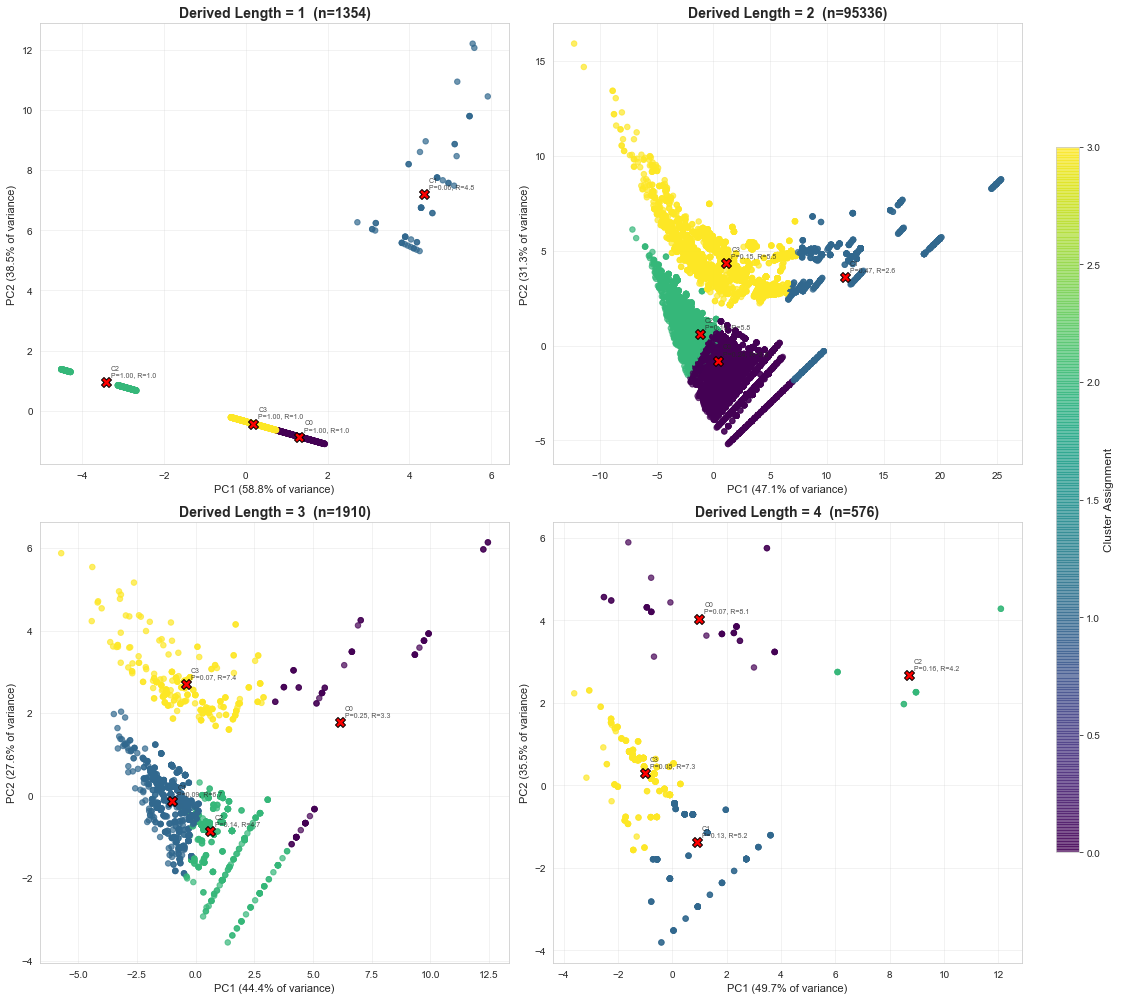


CLUSTER SUMMARIES BY DERIVED LENGTH

--- DL=1 (1354 groups, 4 clusters) ---
            Order  CenterSize        kG   Rank  FittingSize  CommutingProb   Ratio                               Description
Cluster                                                                                                                     
0         138.096     138.096   138.096  1.000      138.096          1.000   1.000  High Commuting (near-abelian) | Low Rank
1         555.462       6.000    33.077  4.808        6.346          0.061  19.001        Very Low Commuting | Moderate Rank
2        1165.124    1165.124  1165.124  1.000     1165.124          1.000   1.000  High Commuting (near-abelian) | Low Rank
3         382.283     382.283   382.283  1.000      382.283          1.000   1.000  High Commuting (near-abelian) | Low Rank

--- DL=2 (95336 groups, 4 clusters) ---
            Order  CenterSize       kG   Rank  FittingSize  CommutingProb  Ratio                         Description
Cluster        

In [20]:
# ============================================================================
# DERIVED LENGTH CLUSTERING VISUALIZATION - ALL IN ONE FIGURE
# WITH CLUSTER LEGEND AND CAPTION
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")

print("="*80)
print("DERIVED LENGTH CLUSTERING - SUBPLOT VISUALIZATION")
print("="*80)

# Define features
features = ['Order', 'CenterSize', 'kG', 'Rank', 'FittingSize', 'CommutingProb', 'Ratio']

# Get unique derived lengths (excluding those with too few samples)
dl_values = sorted([dl for dl in df['DerivedLength'].unique() if len(df[df['DerivedLength'] == dl]) >= 10])

# Create subplot grid
n_plots = len(dl_values)
n_cols = 2
n_rows = (n_plots + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 7 * n_rows))
axes = axes.flatten() if n_plots > 1 else [axes]

# Store cluster summaries for later
all_cluster_summaries = {}

# Define a color map for clusters
cluster_cmap = plt.cm.get_cmap('viridis')

for idx, dl in enumerate(dl_values):
    ax = axes[idx]
    subset = df[df['DerivedLength'] == dl]
    
    # Prepare data
    X_subset = subset[features].copy()
    X_subset_scaled = StandardScaler().fit_transform(X_subset)
    
    # PCA
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(X_subset_scaled)
    
    # Determine optimal number of clusters (elbow method)
    max_k = min(5, len(subset)//10 + 1)
    inertias = []
    for k in range(1, max_k + 1):
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(X_subset_scaled)
        inertias.append(kmeans.inertia_)
    
    # Find elbow point (simplified)
    if len(inertias) > 2:
        diffs = np.diff(inertias)
        if len(diffs) > 1:
            k_opt = np.argmin(np.diff(diffs)) + 2
        else:
            k_opt = 2
    else:
        k_opt = 2
    k_opt = min(k_opt, max_k)
    
    # Fit final k-means
    kmeans = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(X_subset_scaled)
    subset = subset.copy()
    subset['Cluster'] = clusters
    
    # Store summary
    all_cluster_summaries[dl] = subset.groupby('Cluster')[features].mean().round(3)
    
    # Get cluster center descriptions for legend
    cluster_centers = subset.groupby('Cluster')[['CommutingProb', 'Rank', 'Ratio']].mean().round(3)
    
    # Plot with cluster labels
    scatter = ax.scatter(pca_result[:, 0], pca_result[:, 1], 
                         c=clusters, cmap='viridis', alpha=0.7, s=30)
    
    # Add cluster centers as larger points with black edges
    for c in range(k_opt):
        mask = clusters == c
        center_x = pca_result[mask, 0].mean()
        center_y = pca_result[mask, 1].mean()
        ax.scatter(center_x, center_y, c='red', s=100, edgecolor='black', 
                   marker='X', zorder=5)
        # Add cluster label
        cp = cluster_centers.loc[c, 'CommutingProb']
        rk = cluster_centers.loc[c, 'Rank']
        rt = cluster_centers.loc[c, 'Ratio']
        ax.annotate(f'C{c}\nP={cp:.2f}, R={rk:.1f}', 
                    xy=(center_x, center_y), xytext=(5, 5),
                    textcoords='offset points', fontsize=7, alpha=0.8)
    
    ax.set_title(f'Derived Length = {dl}  (n={len(subset)})', fontsize=14, fontweight='bold')
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% of variance)', fontsize=11)
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% of variance)', fontsize=11)
    ax.grid(True, alpha=0.3)

# Hide any unused subplots
for j in range(len(dl_values), len(axes)):
    axes[j].set_visible(False)

# Add a single colorbar for the entire figure
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = fig.colorbar(scatter, cax=cbar_ax)
cbar.set_label('Cluster Assignment', fontsize=12)

plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()

# ============================================================================
# PRINT CLUSTER SUMMARIES WITH DESCRIPTIVE LABELS
# ============================================================================

print("\n" + "="*80)
print("CLUSTER SUMMARIES BY DERIVED LENGTH")
print("="*80)

cluster_descriptions = {}

for dl, summary in all_cluster_summaries.items():
    print(f"\n--- DL={dl} ({len(df[df['DerivedLength'] == dl])} groups, {len(summary)} clusters) ---")
    
    # Add descriptive labels
    descriptions = []
    for c in summary.index:
        row = summary.loc[c]
        if row['CommutingProb'] > 0.8:
            desc = "High Commuting (near-abelian)"
        elif row['CommutingProb'] > 0.2:
            desc = "Moderate Commuting"
        elif row['CommutingProb'] > 0.1:
            desc = "Low Commuting"
        else:
            desc = "Very Low Commuting"
        
        if row['Rank'] < 3:
            desc += " | Low Rank"
        elif row['Rank'] < 5:
            desc += " | Moderate Rank"
        else:
            desc += " | High Rank"
        
        descriptions.append(desc)
    
    summary['Description'] = descriptions
    print(summary.to_string())

RANK PATTERN ANALYSIS

=== 1. DISTRIBUTION OF RANK ===

1      1303
2      1752
3     25914
4     28790
5     21365
6     10277
7      5331
8      2901
9      1143
10      132
11       88
12       77
13       67
14       13
15       24
16        4
17        1
19        1
20        2
Name: Rank, dtype: int64

Groups with Rank 3-5: 76069 (76.7%)

=== 2. MEAN INVARIANTS BY RANK ===

          Order  CenterSize        kG  FittingSize  CommutingProb    Ratio
Rank                                                                      
1      459.3730    459.3730  459.3730     459.3730         1.0000   1.0000
2      354.6587     60.4315  172.7728     354.6587         0.4661   2.6240
3      335.3946     13.8700   85.0883     262.5921         0.2487   4.4994
4      273.5697      8.7233   60.9889     253.9151         0.2255   4.5711
5      322.6799      6.6852   56.5868     244.0403         0.1773   5.9491
6      462.3870      5.3833   63.9268     194.1212         0.1462   7.3987
7      413.4744  

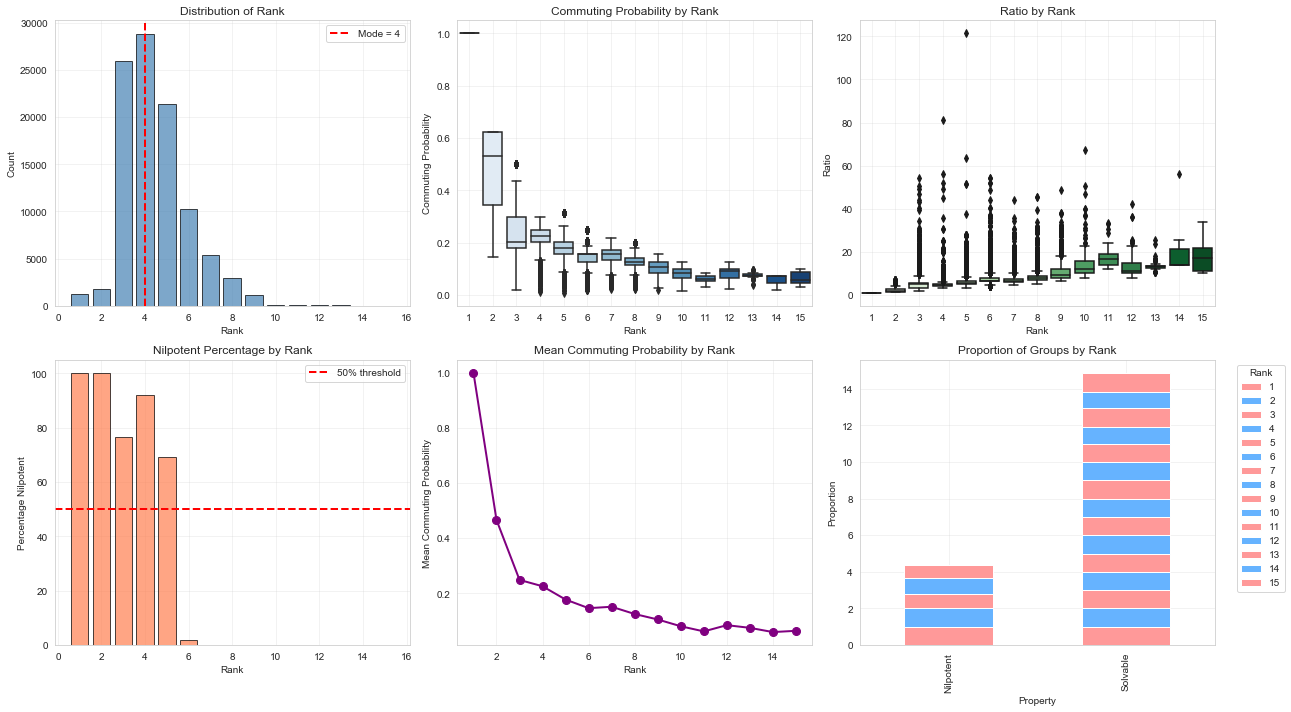


=== 6. CLUSTERING WITHIN RANK ===



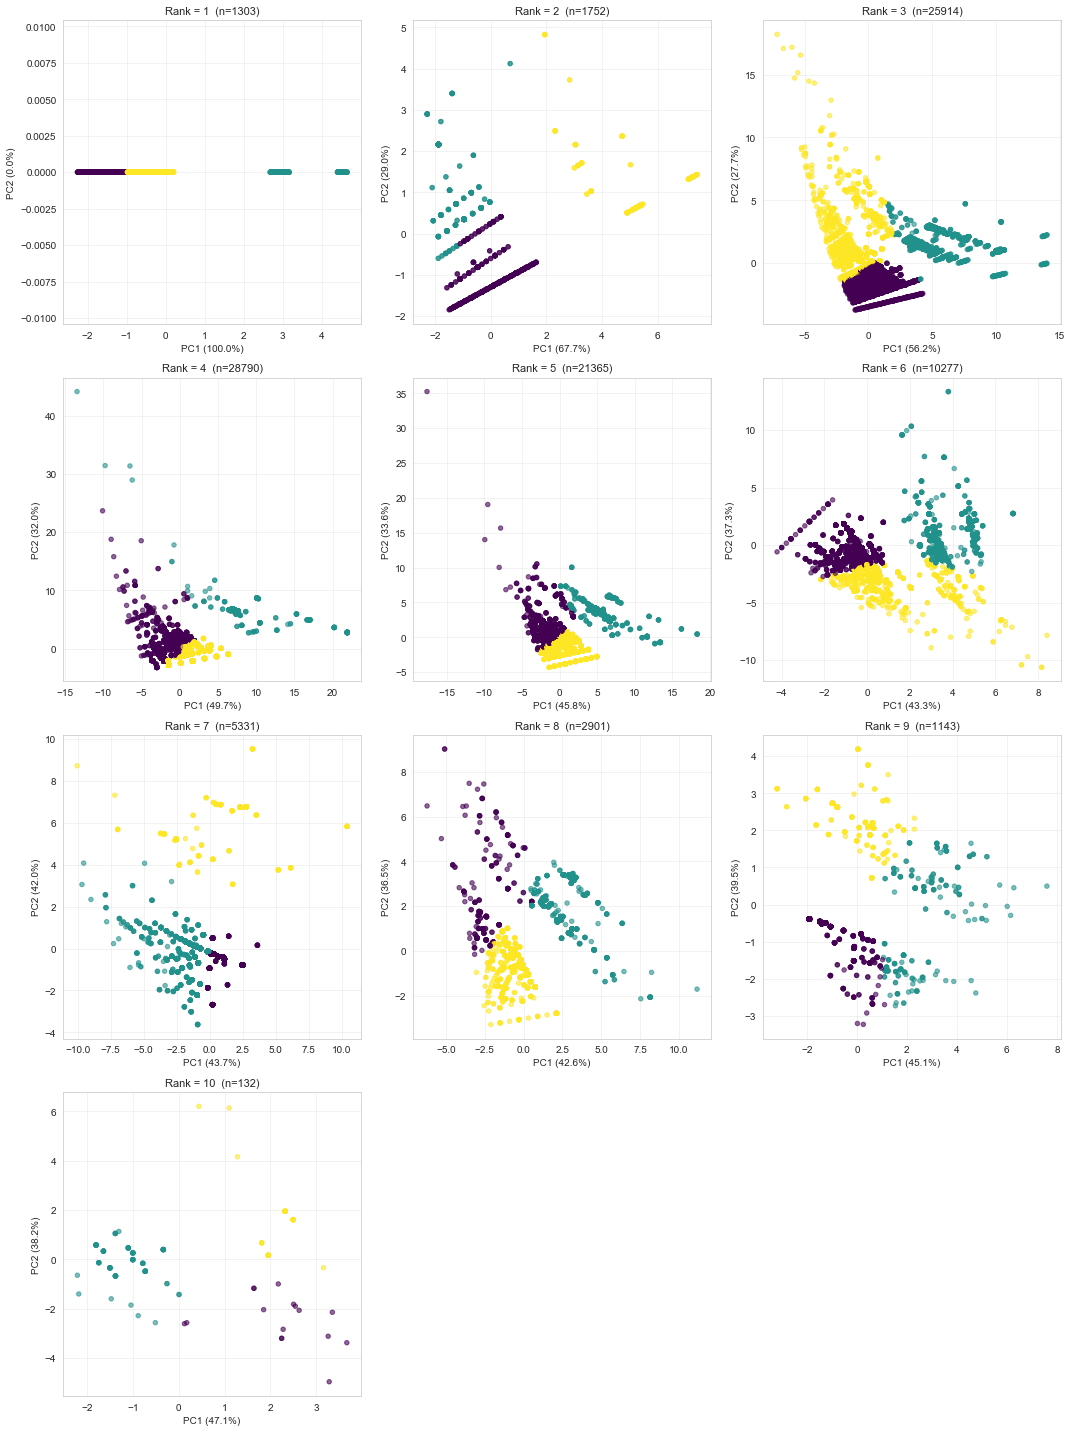


=== 7. SUMMARY TABLE: RANK PATTERNS ===

 Rank  Count  Mean Order  Mean CommutingProb  Mean Ratio  Mean CenterSize   Mean kG  % Nilpotent  % Solvable  Mean DerivedLength
    1   1303    459.3730              1.0000      1.0000         459.3730  459.3730     100.0000    100.0000              0.9992
    2   1752    354.6587              0.4661      2.6240          60.4315  172.7728     100.0000    100.0000              2.0000
    3  25914    335.3946              0.2487      4.4994          13.8700   85.0883      76.6343    100.0000              2.0061
    4  28790    273.5697              0.2255      4.5711           8.7233   60.9889      91.9764     99.8784              2.0118
    5  21365    322.6799              0.1773      5.9491           6.6852   56.5868      69.1786     99.9672              2.0336
    6  10277    462.3870              0.1462      7.3987           5.3833   63.9268       2.0337     99.8832              2.0740
    7   5331    413.4744              0.1513      7.078

In [23]:
# ============================================================================
# RANK PATTERN ANALYSIS: What characterizes groups of a given rank?
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
sns.set_palette("husl")

print("="*80)
print("RANK PATTERN ANALYSIS")
print("="*80)

# Define features
features = ['Order', 'CenterSize', 'kG', 'FittingSize', 'CommutingProb', 'Ratio']

# ============================================================================
# 1. BASIC STATISTICS BY RANK
# ============================================================================

print("\n=== 1. DISTRIBUTION OF RANK ===\n")
rank_counts = df['Rank'].value_counts().sort_index()
print(rank_counts)

# Percentage of groups with rank 3-5
rank_3_5 = df[df['Rank'].between(3, 5)].shape[0]
print(f"\nGroups with Rank 3-5: {rank_3_5} ({rank_3_5/len(df)*100:.1f}%)")

# ============================================================================
# 2. MEAN INVARIANTS BY RANK
# ============================================================================

print("\n=== 2. MEAN INVARIANTS BY RANK ===\n")
rank_groups = df.groupby('Rank')
rank_summary = rank_groups[features].mean().round(4)
print(rank_summary.head(15))

# ============================================================================
# 3. STRUCTURAL PROPERTIES BY RANK
# ============================================================================

print("\n=== 3. STRUCTURAL PROPERTIES BY RANK ===\n")
rank_properties = rank_groups.agg({
    'Nilpotent': 'mean',
    'Solvable': 'mean',
    'DerivedLength': 'mean',
    'FittingDerivedLength': 'mean'
}).round(4)
rank_properties.columns = ['% Nilpotent', '% Solvable', 'Mean DerivedLength', 'Mean FittingDerivedLength']
print(rank_properties.head(15))

# ============================================================================
# 4. TRANSITION ANALYSIS - WHERE ARE THE JUMPS?
# ============================================================================

print("\n=== 4. TRANSITION ANALYSIS ===\n")

# Compute percentage changes between consecutive ranks
rank_means = rank_summary
transitions = {}
for col in features:
    values = rank_means[col].values
    pct_changes = []
    for i in range(len(values)-1):
        if values[i] > 0:
            pct_changes.append((values[i+1] - values[i]) / values[i] * 100)
        else:
            pct_changes.append(np.nan)
    transitions[col] = pct_changes

trans_df = pd.DataFrame(transitions, index=[f"{i}->{i+1}" for i in range(len(rank_means)-1)])
print("Percentage changes between consecutive ranks:\n")
print(trans_df.round(2).head(10))

# ============================================================================
# 5. NON-SOLVABLE GROUPS BY RANK
# ============================================================================

print("\n=== 5. NON-SOLVABLE GROUPS BY RANK ===\n")
non_solv_by_rank = df[df['Solvable'] == False]['Rank'].value_counts().sort_index()
print("Rank distribution of non-solvable groups:")
print(non_solv_by_rank)

if len(non_solv_by_rank) > 0:
    first_non_solv_rank = non_solv_by_rank.index[0]
    print(f"\nFirst non-solvable group appears at Rank: {first_non_solv_rank}")

# ============================================================================
# 6. VISUALIZATION - ALL IN ONE FIGURE
# ============================================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Limit to ranks with sufficient data for visualization
max_rank_display = 15
rank_data = df[df['Rank'] <= max_rank_display]

# 1. Count of groups by Rank
ax1 = axes[0, 0]
rank_counts_filtered = rank_data['Rank'].value_counts().sort_index()
ax1.bar(rank_counts_filtered.index, rank_counts_filtered.values, 
        color='steelblue', edgecolor='black', alpha=0.7)
ax1.axvline(x=df['Rank'].mode()[0], color='red', linestyle='--', linewidth=2, 
            label=f"Mode = {df['Rank'].mode()[0]}")
ax1.set_xlabel('Rank')
ax1.set_ylabel('Count')
ax1.set_title('Distribution of Rank')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Commuting Probability by Rank
ax2 = axes[0, 1]
sns.boxplot(data=rank_data, x='Rank', y='CommutingProb', ax=ax2, palette='Blues')
ax2.set_title('Commuting Probability by Rank')
ax2.set_xlabel('Rank')
ax2.set_ylabel('Commuting Probability')
ax2.grid(True, alpha=0.3)

# 3. Ratio by Rank
ax3 = axes[0, 2]
sns.boxplot(data=rank_data, x='Rank', y='Ratio', ax=ax3, palette='Greens')
ax3.set_title('Ratio by Rank')
ax3.set_xlabel('Rank')
ax3.set_ylabel('Ratio')
ax3.grid(True, alpha=0.3)

# 4. Percentage Nilpotent by Rank
ax4 = axes[1, 0]
rank_nilpotent = df.groupby('Rank')['Nilpotent'].mean() * 100
rank_nilpotent = rank_nilpotent[rank_nilpotent.index <= max_rank_display]
ax4.bar(rank_nilpotent.index, rank_nilpotent.values, 
        color='coral', edgecolor='black', alpha=0.7)
ax4.axhline(y=50, color='red', linestyle='--', linewidth=2, label='50% threshold')
ax4.set_xlabel('Rank')
ax4.set_ylabel('Percentage Nilpotent')
ax4.set_title('Nilpotent Percentage by Rank')
ax4.legend()
ax4.grid(True, alpha=0.3)

# 5. Mean Commuting Probability by Rank
ax5 = axes[1, 1]
rank_comm = df.groupby('Rank')['CommutingProb'].mean()
rank_comm = rank_comm[rank_comm.index <= max_rank_display]
ax5.plot(rank_comm.index, rank_comm.values, 'o-', color='purple', linewidth=2, markersize=8)
ax5.set_xlabel('Rank')
ax5.set_ylabel('Mean Commuting Probability')
ax5.set_title('Mean Commuting Probability by Rank')
ax5.grid(True, alpha=0.3)

# 6. Heatmap: Rank vs Nilpotent/Solvable
ax6 = axes[1, 2]
rank_prop = df.groupby('Rank')[['Nilpotent', 'Solvable']].mean()
rank_prop = rank_prop[rank_prop.index <= max_rank_display]
rank_prop.T.plot(kind='bar', stacked=True, ax=ax6, color=['#ff9999', '#66b3ff'])
ax6.set_xlabel('Property')
ax6.set_ylabel('Proportion')
ax6.set_title('Proportion of Groups by Rank')
ax6.legend(title='Rank', bbox_to_anchor=(1.05, 1), loc='upper left')
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================================
# 7. CLUSTERING WITHIN EACH RANK
# ============================================================================

print("\n=== 6. CLUSTERING WITHIN RANK ===\n")

# Focus on ranks with sufficient data
rank_values = sorted([r for r in df['Rank'].unique() if len(df[df['Rank'] == r]) >= 30])
rank_values = [r for r in rank_values if r <= 10]  # Limit to first 10 ranks

n_plots = len(rank_values)
n_cols = 3
n_rows = (n_plots + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten() if n_plots > 1 else [axes]

for idx, rank_val in enumerate(rank_values):
    ax = axes[idx]
    subset = df[df['Rank'] == rank_val]
    
    if len(subset) < 10:
        ax.text(0.5, 0.5, f'Rank={rank_val}: n={len(subset)}', 
                ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'Rank = {rank_val}')
        continue
    
    # Prepare data
    X_subset = subset[features].copy()
    X_subset_scaled = StandardScaler().fit_transform(X_subset)
    
    # PCA
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(X_subset_scaled)
    
    # K-means clustering
    k_opt = min(3, len(subset)//20 + 1)
    kmeans = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(X_subset_scaled)
    
    scatter = ax.scatter(pca_result[:, 0], pca_result[:, 1], 
                         c=clusters, cmap='viridis', alpha=0.6, s=20)
    ax.set_title(f'Rank = {rank_val}  (n={len(subset)})', fontsize=11)
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    ax.grid(True, alpha=0.3)

for j in range(len(rank_values), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

# ============================================================================
# 8. SUMMARY TABLE FOR PAPER
# ============================================================================

print("\n=== 7. SUMMARY TABLE: RANK PATTERNS ===\n")

summary_rows = []
for rank_val in sorted(df['Rank'].unique()):
    subset = df[df['Rank'] == rank_val]
    if len(subset) < 10:
        continue
    row = {
        'Rank': rank_val,
        'Count': len(subset),
        'Mean Order': subset['Order'].mean(),
        'Mean CommutingProb': subset['CommutingProb'].mean(),
        'Mean Ratio': subset['Ratio'].mean(),
        'Mean CenterSize': subset['CenterSize'].mean(),
        'Mean kG': subset['kG'].mean(),
        '% Nilpotent': subset['Nilpotent'].mean() * 100,
        '% Solvable': subset['Solvable'].mean() * 100,
        'Mean DerivedLength': subset['DerivedLength'].mean(),
    }
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
print(summary_df.round(4).to_string(index=False))


In [17]:
import pandas as pd

# Convert Boolean strings to Boolean values if necessary
df["Nilpotent"] = df["Nilpotent"].astype(str).str.lower() == "true"
df["Solvable"] = df["Solvable"].astype(str).str.lower() == "true"


# Group by Rank and compute statistics
rank_table = df.groupby("Rank").agg(
    Number_of_Groups=("Rank", "count"),
    Nilpotent_Groups=("Nilpotent", "sum"),
    Solvable_Groups=("Solvable", "sum")
).reset_index()


# Add non-solvable groups
rank_table["Non_Solvable_Groups"] = (
    rank_table["Number_of_Groups"]
    -
    rank_table["Solvable_Groups"]
)


# Percentages
rank_table["Percent_Nilpotent"] = (
    100 *
    rank_table["Nilpotent_Groups"]
    /
    rank_table["Number_of_Groups"]
)


rank_table["Percent_Solvable"] = (
    100 *
    rank_table["Solvable_Groups"]
    /
    rank_table["Number_of_Groups"]
)


# Sort by rank
rank_table = rank_table.sort_values("Rank")


rank_table

,Rank,Number_of_Groups,Nilpotent_Groups,Solvable_Groups,Non_Solvable_Groups,Percent_Nilpotent,Percent_Solvable
0,1,1303,1303.0,1303.0,0.0,100.000000,100.000000
1,2,1752,1752.0,1752.0,0.0,100.000000,100.000000
2,3,25914,19859.0,25914.0,0.0,76.634252,100.000000
3,4,28790,26480.0,28755.0,35.0,91.976381,99.878430
4,5,21365,14780.0,21358.0,7.0,69.178563,99.967236
5,6,10277,209.0,10265.0,12.0,2.033667,99.883234
6,7,5331,0.0,5326.0,5.0,0.000000,99.906209
7,8,2901,0.0,2896.0,5.0,0.000000,99.827646
8,9,1143,0.0,1141.0,2.0,0.000000,99.825022
9,10,132,0.0,129.0,3.0,0.000000,97.727273


In [18]:
rank_property_table = pd.crosstab(
    df["kG"],
    [
        df["Nilpotent"],
        df["Solvable"]
    ]
)

rank_property_table.head(20)

Nilpotent False       True 
Solvable  False True  True 
kG                         
1             0     0     1
2             0     0     1
3             0     1     1
4             0     2     2
5             1     4     3
6             1     6     1
7             2     6     4
8             0    15     3
9             3    16     2
10            1    24     7
11            1    16    11
12            4    34     2
13            0    37     7
14            2    47    24
15            3    45     3
16            0    49    29
17            1    36    21
18            7   102     2
19            3    42    51
20            2    83    42

In [23]:
df.columns

Index(['Order', 'GroupID', 'CenterSize', 'kG', 'ClassSizes', 'Rank',
       'Nilpotent', 'Solvable', 'DerivedLength', 'FittingDerivedLength',
       'FittingSize', 'PrimeDivisors', 'CommutingProb', 'Ratio',
       'Solvable_numeric'],
      dtype='object')

In [24]:
df = df[['Order', 'CenterSize', 'kG',  'Rank',  'Nilpotent', 'Solvable', 'DerivedLength', 
         'FittingDerivedLength','FittingSize', 'PrimeDivisors', 'CommutingProb', 'Ratio']]

In [25]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Order,99185.0,344.730383,222.937925,1.000000,256.000000,256.000000,384.000000,1400.000000
CenterSize,99185.0,15.717135,70.869297,1.000000,4.000000,8.000000,8.000000,1400.000000
kG,99185.0,73.840177,85.200153,1.000000,46.000000,54.000000,66.000000,1400.000000
Rank,99185.0,4.454030,1.538447,1.000000,3.000000,4.000000,5.000000,20.000000
DerivedLength,99185.0,2.017089,0.237191,0.000000,2.000000,2.000000,2.000000,5.000000
FittingDerivedLength,99185.0,1.887211,0.330276,0.000000,2.000000,2.000000,2.000000,3.000000
FittingSize,99185.0,245.194273,117.022709,1.000000,192.000000,256.000000,256.000000,1400.000000
CommutingProb,99185.0,0.218451,0.119109,0.008242,0.166667,0.203125,0.234375,1.000000
Ratio,99185.0,5.430997,2.611256,1.000000,4.266667,4.923077,6.000000,121.333333


In [26]:
df[df["CommutingProb"]==1].count()

Order                   1303
CenterSize              1303
kG                      1303
Rank                    1303
Nilpotent               1303
Solvable                1303
DerivedLength           1303
FittingDerivedLength    1303
FittingSize             1303
PrimeDivisors           1303
CommutingProb           1303
Ratio                   1303
dtype: int64

In [27]:
!pip install imbalanced-learn

  Using cached imbalanced_learn-0.12.4-py3-none-any.whl (258 kB)
  Using cached scipy-1.7.3-cp37-cp37m-win32.whl (30.6 MB)
  Using cached joblib-1.3.2-py3-none-any.whl (302 kB)
  Using cached scikit_learn-1.0.2-cp37-cp37m-win32.whl (6.4 MB)
  Attempting uninstall: scipy
    Found existing installation: scipy 1.4.1
    Uninstalling scipy-1.4.1:


ERROR: Could not install packages due to an EnvironmentError: [WinError 5] Accès refusé: 'c:\\programdata\\anaconda3\\lib\\site-packages\\scipy-1.4.1.dist-info\\INSTALLER'
Consider using the `--user` option or check the permissions.



In [28]:
correlation_matrix = df.corr()
correlation_matrix

,Order,CenterSize,kG,Rank,Nilpotent,Solvable,DerivedLength,FittingDerivedLength,FittingSize,CommutingProb,Ratio
Order,1.000000,0.232425,0.581950,0.234300,-0.475156,-0.030155,0.020234,-0.429285,0.550039,-0.055225,0.324391
CenterSize,0.232425,1.000000,0.844803,-0.246254,0.080202,0.004252,-0.364188,-0.235894,0.520672,0.630808,-0.202438
kG,0.581950,0.844803,1.000000,-0.245468,-0.083205,0.014381,-0.293683,-0.357684,0.761435,0.590864,-0.253039
Rank,0.234300,-0.246254,-0.245468,1.000000,-0.567209,-0.024578,0.265534,0.047171,-0.293374,-0.568384,0.573512
Nilpotent,-0.475156,0.080202,-0.083205,-0.567209,1.000000,0.037165,-0.175129,0.409097,0.251689,0.253726,-0.373159
Solvable,-0.030155,0.004252,0.014381,-0.024578,0.037165,1.000000,0.104716,0.075638,0.055880,0.037826,-0.198500
DerivedLength,0.020234,-0.364188,-0.293683,0.265534,-0.175129,0.104716,1.000000,0.186383,-0.235673,-0.479523,0.353662
FittingDerivedLength,-0.429285,-0.235894,-0.357684,0.047171,0.409097,0.075638,0.186383,1.000000,0.025626,-0.254595,-0.097127
FittingSize,0.550039,0.520672,0.761435,-0.293374,0.251689,0.055880,-0.235673,0.025626,1.000000,0.301390,-0.236907
CommutingProb,-0.055225,0.630808,0.590864,-0.568384,0.253726,0.037826,-0.479523,-0.254595,0.301390,1.000000,-0.599334


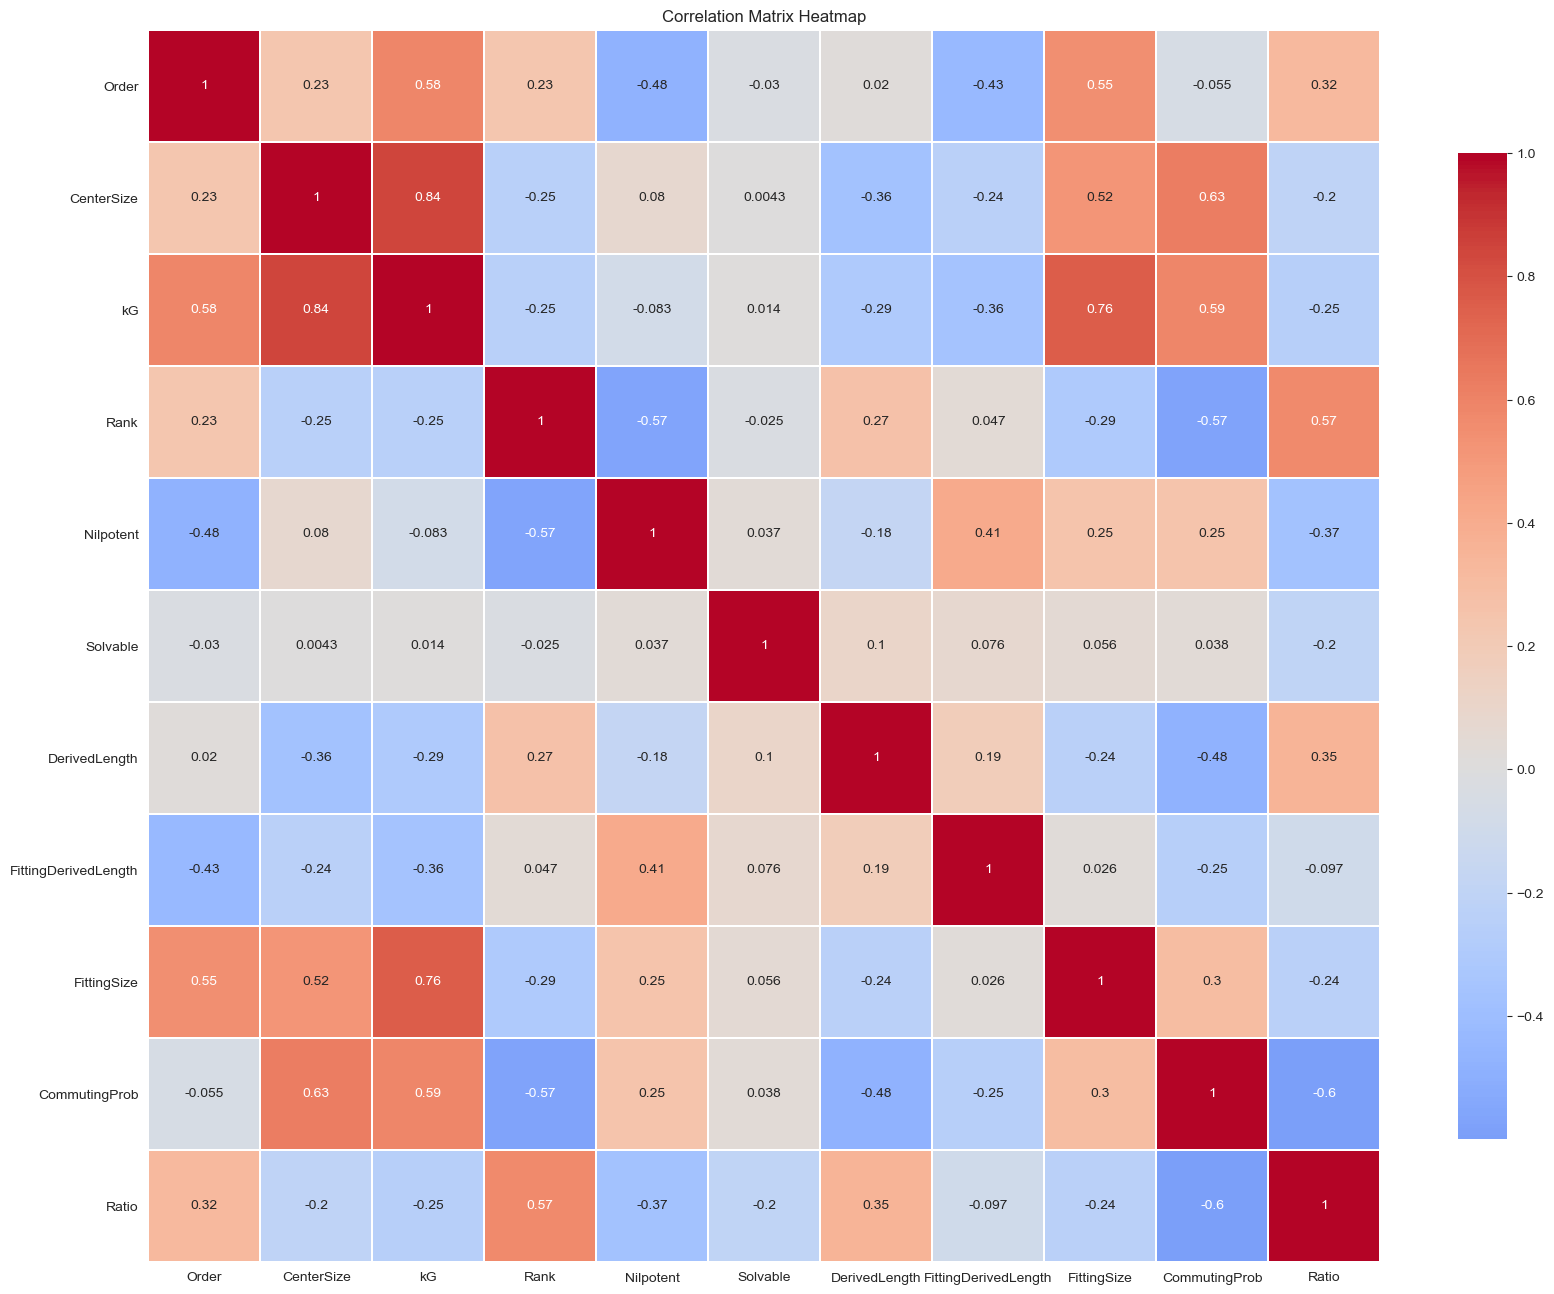

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 16))
sns.heatmap(correlation_matrix, 
            annot=True,           # Show values
            cmap='coolwarm',      # Color scheme
            center=0,             # Center colormap at 0
            square=True,          # Square cells
            linewidths=0.5,       # Grid lines
            cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix Heatmap')
plt.show()

In [30]:
df.columns

Index(['Order', 'CenterSize', 'kG', 'Rank', 'Nilpotent', 'Solvable',
       'DerivedLength', 'FittingDerivedLength', 'FittingSize', 'PrimeDivisors',
       'CommutingProb', 'Ratio'],
      dtype='object')

In [31]:
# Pearson (default) - linear correlation
pearson_corr = df.corr(method='pearson')

# Spearman - rank correlation (non-parametric)
spearman_corr = df.corr(method='spearman')

# Kendall - ordinal correlation
kendall_corr = df.corr(method='kendall')

In [32]:

# Find highly correlated pairs
def get_high_correlations(df, threshold=0.7):
    corr_matrix = df.corr()
    high_corr = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i, j]) > threshold:
                high_corr.append((
                    corr_matrix.columns[i],
                    corr_matrix.columns[j],
                    corr_matrix.iloc[i, j]
                ))
    return sorted(high_corr, key=lambda x: abs(x[2]), reverse=True)

high_corr_pairs = get_high_correlations(df, threshold=0.5)
print("Highly correlated pairs:")
for pair in high_corr_pairs:
    print(f"{pair[0]} - {pair[1]}: {pair[2]:.3f}")

Highly correlated pairs:
CenterSize - kG: 0.845
kG - FittingSize: 0.761
CenterSize - CommutingProb: 0.631
CommutingProb - Ratio: -0.599
kG - CommutingProb: 0.591
Order - kG: 0.582
Rank - Ratio: 0.574
Rank - CommutingProb: -0.568
Rank - Nilpotent: -0.567
Order - FittingSize: 0.550
CenterSize - FittingSize: 0.521


In [34]:
from itertools import combinations
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.multioutput import MultiOutputClassifier
import pandas as pd

features = ['Order', 'CenterSize', 'kG', 'Rank',
            'FittingSize', 'CommutingProb', 'Ratio']

results = []

for pair in combinations(features, 2):
    
    X = df[list(pair)]
    y = df[['Nilpotent', 'Solvable', 'DerivedLength', 'FittingDerivedLength']]
    
    # Ensure all targets are integer/categorical
    y = y.astype(int)
    
    # Create stratification labels (combine Nilpotent and Solvable)
    stratify_labels = (
        df["Nilpotent"].astype(str) + "_" +
        df["Solvable"].astype(str)
    )
    
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.30,
        random_state=42,
        stratify=stratify_labels
    )
    
    # Use MultiOutputClassifier for multiple classification targets
    clf = MultiOutputClassifier(
        DecisionTreeClassifier(max_depth=3, random_state=42)
    )
    
    clf.fit(X_train, y_train)
    
    pred = clf.predict(X_test)
    
    # Calculate accuracies for each target
    nil_acc = accuracy_score(y_test["Nilpotent"], pred[:, 0])
    solv_acc = accuracy_score(y_test["Solvable"], pred[:, 1])
    derived_acc = accuracy_score(y_test["DerivedLength"], pred[:, 2])
    fitting_acc = accuracy_score(y_test["FittingDerivedLength"], pred[:, 3])
    joint_acc = (pred == y_test.values).all(axis=1).mean()
    
    results.append({
        "Invariant Pair": pair,
        "Nilpotent Accuracy": nil_acc,
        "Solvable Accuracy": solv_acc,
        "DerivedLength Accuracy": derived_acc,
        "FittingDerivedLength Accuracy": fitting_acc,
        "Joint Accuracy": joint_acc
    })

results = pd.DataFrame(results)
results = results.sort_values("Joint Accuracy", ascending=False)
results

,Invariant Pair,Nilpotent Accuracy,Solvable Accuracy,DerivedLength Accuracy,FittingDerivedLength Accuracy,Joint Accuracy
2,"(Order, Rank)",0.952077,0.999765,0.969216,0.917462,0.876059
15,"(Rank, FittingSize)",0.952043,0.999832,0.972140,0.909161,0.869808
3,"(Order, FittingSize)",0.964041,1.000000,0.959974,0.902104,0.857407
12,"(kG, FittingSize)",0.937391,0.999933,0.952749,0.916555,0.846081
19,"(FittingSize, Ratio)",0.948884,1.000000,0.970527,0.855962,0.826254
18,"(FittingSize, CommutingProb)",0.948884,1.000000,0.970527,0.855962,0.826254
0,"(Order, CenterSize)",0.943104,0.999832,0.964646,0.886678,0.822389
5,"(Order, Ratio)",0.948918,0.999832,0.969922,0.857407,0.820473
4,"(Order, CommutingProb)",0.948918,0.999832,0.969922,0.857407,0.820473
8,"(CenterSize, FittingSize)",0.940281,0.999664,0.966528,0.885401,0.819532


In [35]:
from itertools import combinations
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.multioutput import MultiOutputClassifier
import pandas as pd

features = ['Order', 'CenterSize', 'kG', 'Rank',
            'FittingSize', 'CommutingProb', 'Ratio']

results = []

for pair in combinations(features, 2):
    
    X = df[list(pair)]
    y = df[['Nilpotent', 'Solvable', 'DerivedLength', 'FittingDerivedLength']]
    
    # Ensure all targets are integer/categorical
    y = y.astype(int)
    
    # Create stratification labels (combine Nilpotent and Solvable)
    stratify_labels = (
        df["Nilpotent"].astype(str) + "_" +
        df["Solvable"].astype(str)
    )
    
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.30,
        random_state=42,
        stratify=stratify_labels
    )
    
    # Use MultiOutputClassifier with Random Forest
    clf = MultiOutputClassifier(
        RandomForestClassifier(
            n_estimators=100,      # Number of trees
            max_depth=10,          # Maximum depth of trees
            random_state=42,
            n_jobs=-1              # Use all available cores
        )
    )
    
    clf.fit(X_train, y_train)
    
    pred = clf.predict(X_test)
    
    # Calculate accuracies for each target
    nil_acc = accuracy_score(y_test["Nilpotent"], pred[:, 0])
    solv_acc = accuracy_score(y_test["Solvable"], pred[:, 1])
    derived_acc = accuracy_score(y_test["DerivedLength"], pred[:, 2])
    fitting_acc = accuracy_score(y_test["FittingDerivedLength"], pred[:, 3])
    joint_acc = (pred == y_test.values).all(axis=1).mean()
    
    results.append({
        "Invariant Pair": pair,
        "Nilpotent Accuracy": nil_acc,
        "Solvable Accuracy": solv_acc,
        "DerivedLength Accuracy": derived_acc,
        "FittingDerivedLength Accuracy": fitting_acc,
        "Joint Accuracy": joint_acc
    })

results = pd.DataFrame(results)
results = results.sort_values("Joint Accuracy", ascending=False)
results

,Invariant Pair,Nilpotent Accuracy,Solvable Accuracy,DerivedLength Accuracy,FittingDerivedLength Accuracy,Joint Accuracy
18,"(FittingSize, CommutingProb)",0.995530,0.999966,0.982793,0.974392,0.963638
19,"(FittingSize, Ratio)",0.995766,1.000000,0.982424,0.973686,0.962965
15,"(Rank, FittingSize)",0.992472,0.999832,0.974627,0.977920,0.962293
12,"(kG, FittingSize)",0.975971,1.000000,0.969788,0.972644,0.939777
4,"(Order, CommutingProb)",0.980441,0.999630,0.977147,0.956479,0.929930
2,"(Order, Rank)",0.972375,0.999597,0.970729,0.959403,0.929392
5,"(Order, Ratio)",0.980273,0.999597,0.976946,0.956143,0.929056
17,"(Rank, Ratio)",0.964444,0.999530,0.980811,0.960949,0.925393
16,"(Rank, CommutingProb)",0.964444,0.999530,0.980643,0.960344,0.924956
3,"(Order, FittingSize)",0.999126,1.000000,0.968343,0.936584,0.924486


MULTI-OUTPUT RANDOM FOREST: INDIVIDUAL TARGET ACCURACIES
Nilpotent                : 0.9988
Solvable                 : 1.0000
DerivedLength            : 0.9873
FittingDerivedLength     : 0.9899

Joint Accuracy           : 0.9825

FEATURE IMPORTANCE PER TARGET
       Feature  Nilpotent  Solvable  DerivedLength  FittingDerivedLength  Average
   FittingSize     0.3797    0.6643         0.2631                0.2312   0.3846
         Order     0.3435    0.0555         0.0957                0.1551   0.1625
         Ratio     0.0656    0.0826         0.1775                0.1778   0.1259
 CommutingProb     0.0516    0.0666         0.1590                0.1423   0.1049
            kG     0.0984    0.0625         0.1162                0.0810   0.0895
          Rank     0.0404    0.0182         0.1009                0.1811   0.0851
    CenterSize     0.0207    0.0503         0.0876                0.0316   0.0475


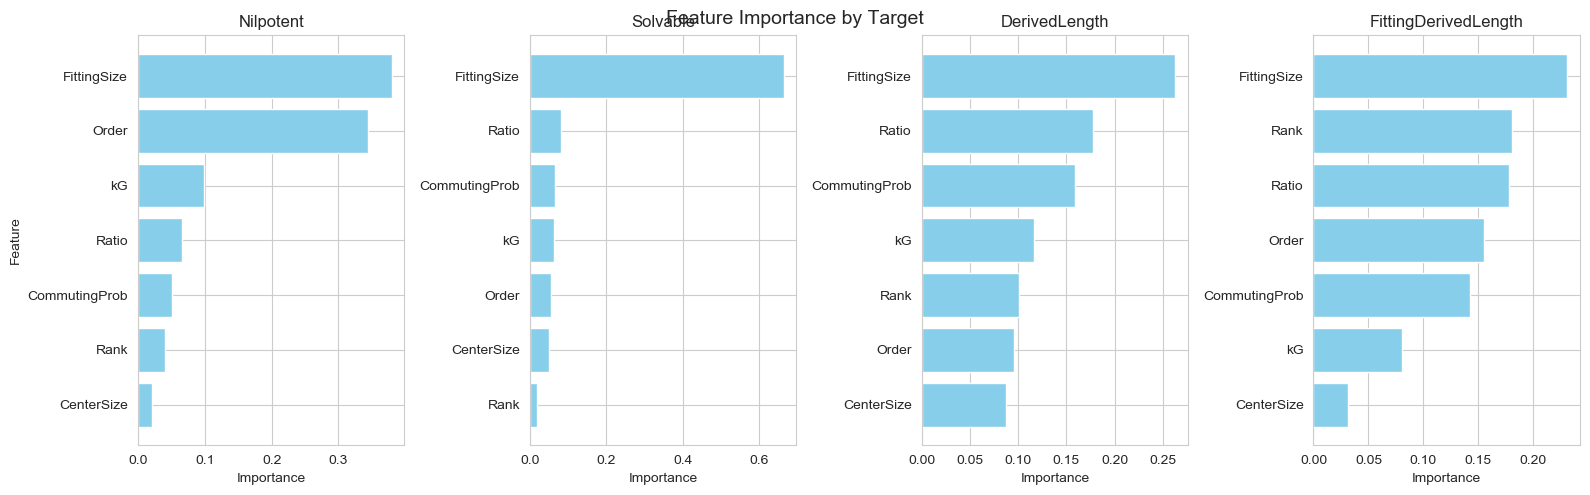


AVERAGE FEATURE IMPORTANCE (ACROSS ALL TARGETS)
       Feature  Average
   FittingSize   0.3846
         Order   0.1625
         Ratio   0.1259
 CommutingProb   0.1049
            kG   0.0895
          Rank   0.0851
    CenterSize   0.0475


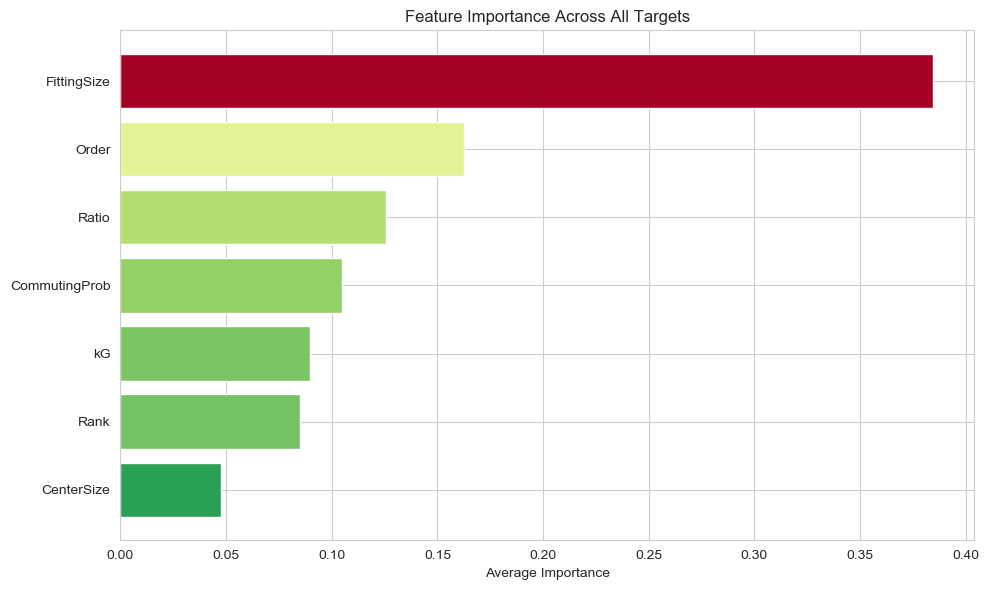


CLASSIFICATION REPORTS PER TARGET

--- Nilpotent ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     13743
           1       1.00      1.00      1.00     16013

    accuracy                           1.00     29756
   macro avg       1.00      1.00      1.00     29756
weighted avg       1.00      1.00      1.00     29756


--- Solvable ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00      1.00     29751

    accuracy                           1.00     29756
   macro avg       1.00      1.00      1.00     29756
weighted avg       1.00      1.00      1.00     29756


--- DerivedLength ---
              precision    recall  f1-score   support

           1       1.00      0.97      0.99       347
           2       0.99      1.00      0.99     28496
           3       0.85      0.61      0.71       696
           4       0.99      0.78 

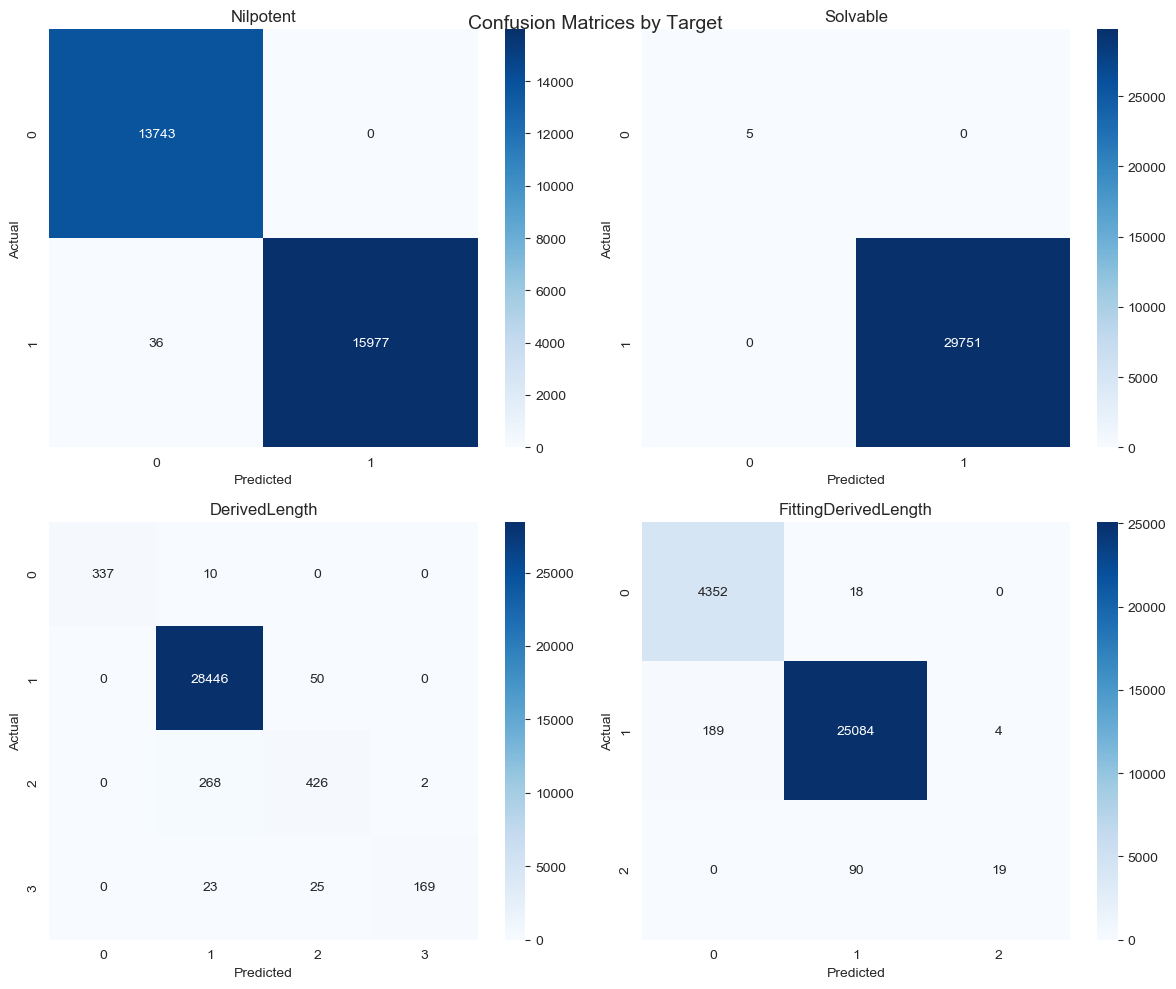

In [37]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define all features
features = ['Order', 'CenterSize', 'kG', 'Rank', 
            'FittingSize', 'CommutingProb', 'Ratio']

# Features
X = df[features]

# Multi-target: predict all four properties
y = df[['Nilpotent', 'Solvable', 'DerivedLength', 'FittingDerivedLength']]
y = y.astype(int)

# Train-test split with stratification on combined target
# (we'll use Nilpotent + Solvable as stratify labels to maintain class balance)
stratify_labels = (
    df["Nilpotent"].astype(str) + "_" +
    df["Solvable"].astype(str)
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=stratify_labels
)

# Train MultiOutput Random Forest
rf_multi = MultiOutputClassifier(
    RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        min_samples_split=5,
        random_state=42,
        n_jobs=-1
    )
)
rf_multi.fit(X_train, y_train)

# Predictions
pred = rf_multi.predict(X_test)

# ============================================================================
# 1. INDIVIDUAL TARGET ACCURACIES
# ============================================================================
target_names = ['Nilpotent', 'Solvable', 'DerivedLength', 'FittingDerivedLength']

print("=" * 60)
print("MULTI-OUTPUT RANDOM FOREST: INDIVIDUAL TARGET ACCURACIES")
print("=" * 60)

individual_accuracies = []
for i, name in enumerate(target_names):
    acc = accuracy_score(y_test[name], pred[:, i])
    individual_accuracies.append(acc)
    print(f"{name:25s}: {acc:.4f}")

# Joint accuracy (all four predictions correct)
joint_acc = (pred == y_test.values).all(axis=1).mean()
print(f"\n{'Joint Accuracy':25s}: {joint_acc:.4f}")

# ============================================================================
# 2. FEATURE IMPORTANCE PER TARGET
# ============================================================================
print("\n" + "=" * 60)
print("FEATURE IMPORTANCE PER TARGET")
print("=" * 60)

importance_dict = {}
for i, name in enumerate(target_names):
    imp = pd.DataFrame({
        'Feature': features,
        name: rf_multi.estimators_[i].feature_importances_
    })
    importance_dict[name] = imp

# Merge all importances into one DataFrame
importance_df = importance_dict['Nilpotent']
for name in target_names[1:]:
    importance_df = importance_df.merge(importance_dict[name], on='Feature')

# Calculate average importance across all targets
importance_df['Average'] = importance_df[target_names].mean(axis=1)
importance_df = importance_df.sort_values('Average', ascending=False)

print(importance_df.to_string(index=False, float_format="%.4f"))

# ============================================================================
# 3. VISUALIZATION: FEATURE IMPORTANCE PER TARGET
# ============================================================================
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle('Feature Importance by Target', fontsize=14)

for i, (ax, name) in enumerate(zip(axes, target_names)):
    imp_sorted = importance_df[['Feature', name]].sort_values(name, ascending=True)
    ax.barh(imp_sorted['Feature'], imp_sorted[name], color='skyblue')
    ax.set_title(name)
    ax.set_xlabel('Importance')
    if i == 0:
        ax.set_ylabel('Feature')

plt.tight_layout()
plt.show()

# ============================================================================
# 4. AVERAGE FEATURE IMPORTANCE
# ============================================================================
print("\n" + "=" * 60)
print("AVERAGE FEATURE IMPORTANCE (ACROSS ALL TARGETS)")
print("=" * 60)
avg_importance = importance_df[['Feature', 'Average']].sort_values('Average', ascending=False)
print(avg_importance.to_string(index=False, float_format="%.4f"))

# Plot average feature importance
plt.figure(figsize=(10, 6))
colors = plt.cm.RdYlGn_r(avg_importance['Average'] / avg_importance['Average'].max())
plt.barh(avg_importance['Feature'], avg_importance['Average'], color=colors)
plt.xlabel('Average Importance')
plt.title('Feature Importance Across All Targets')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# ============================================================================
# 5. CLASSIFICATION REPORTS PER TARGET
# ============================================================================
print("\n" + "=" * 60)
print("CLASSIFICATION REPORTS PER TARGET")
print("=" * 60)

for i, name in enumerate(target_names):
    print(f"\n--- {name} ---")
    print(classification_report(y_test[name], pred[:, i]))

# ============================================================================
# 6. CONFUSION MATRICES
# ============================================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Confusion Matrices by Target', fontsize=14)

for i, (ax, name) in enumerate(zip(axes.flatten(), target_names)):
    cm = confusion_matrix(y_test[name], pred[:, i])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

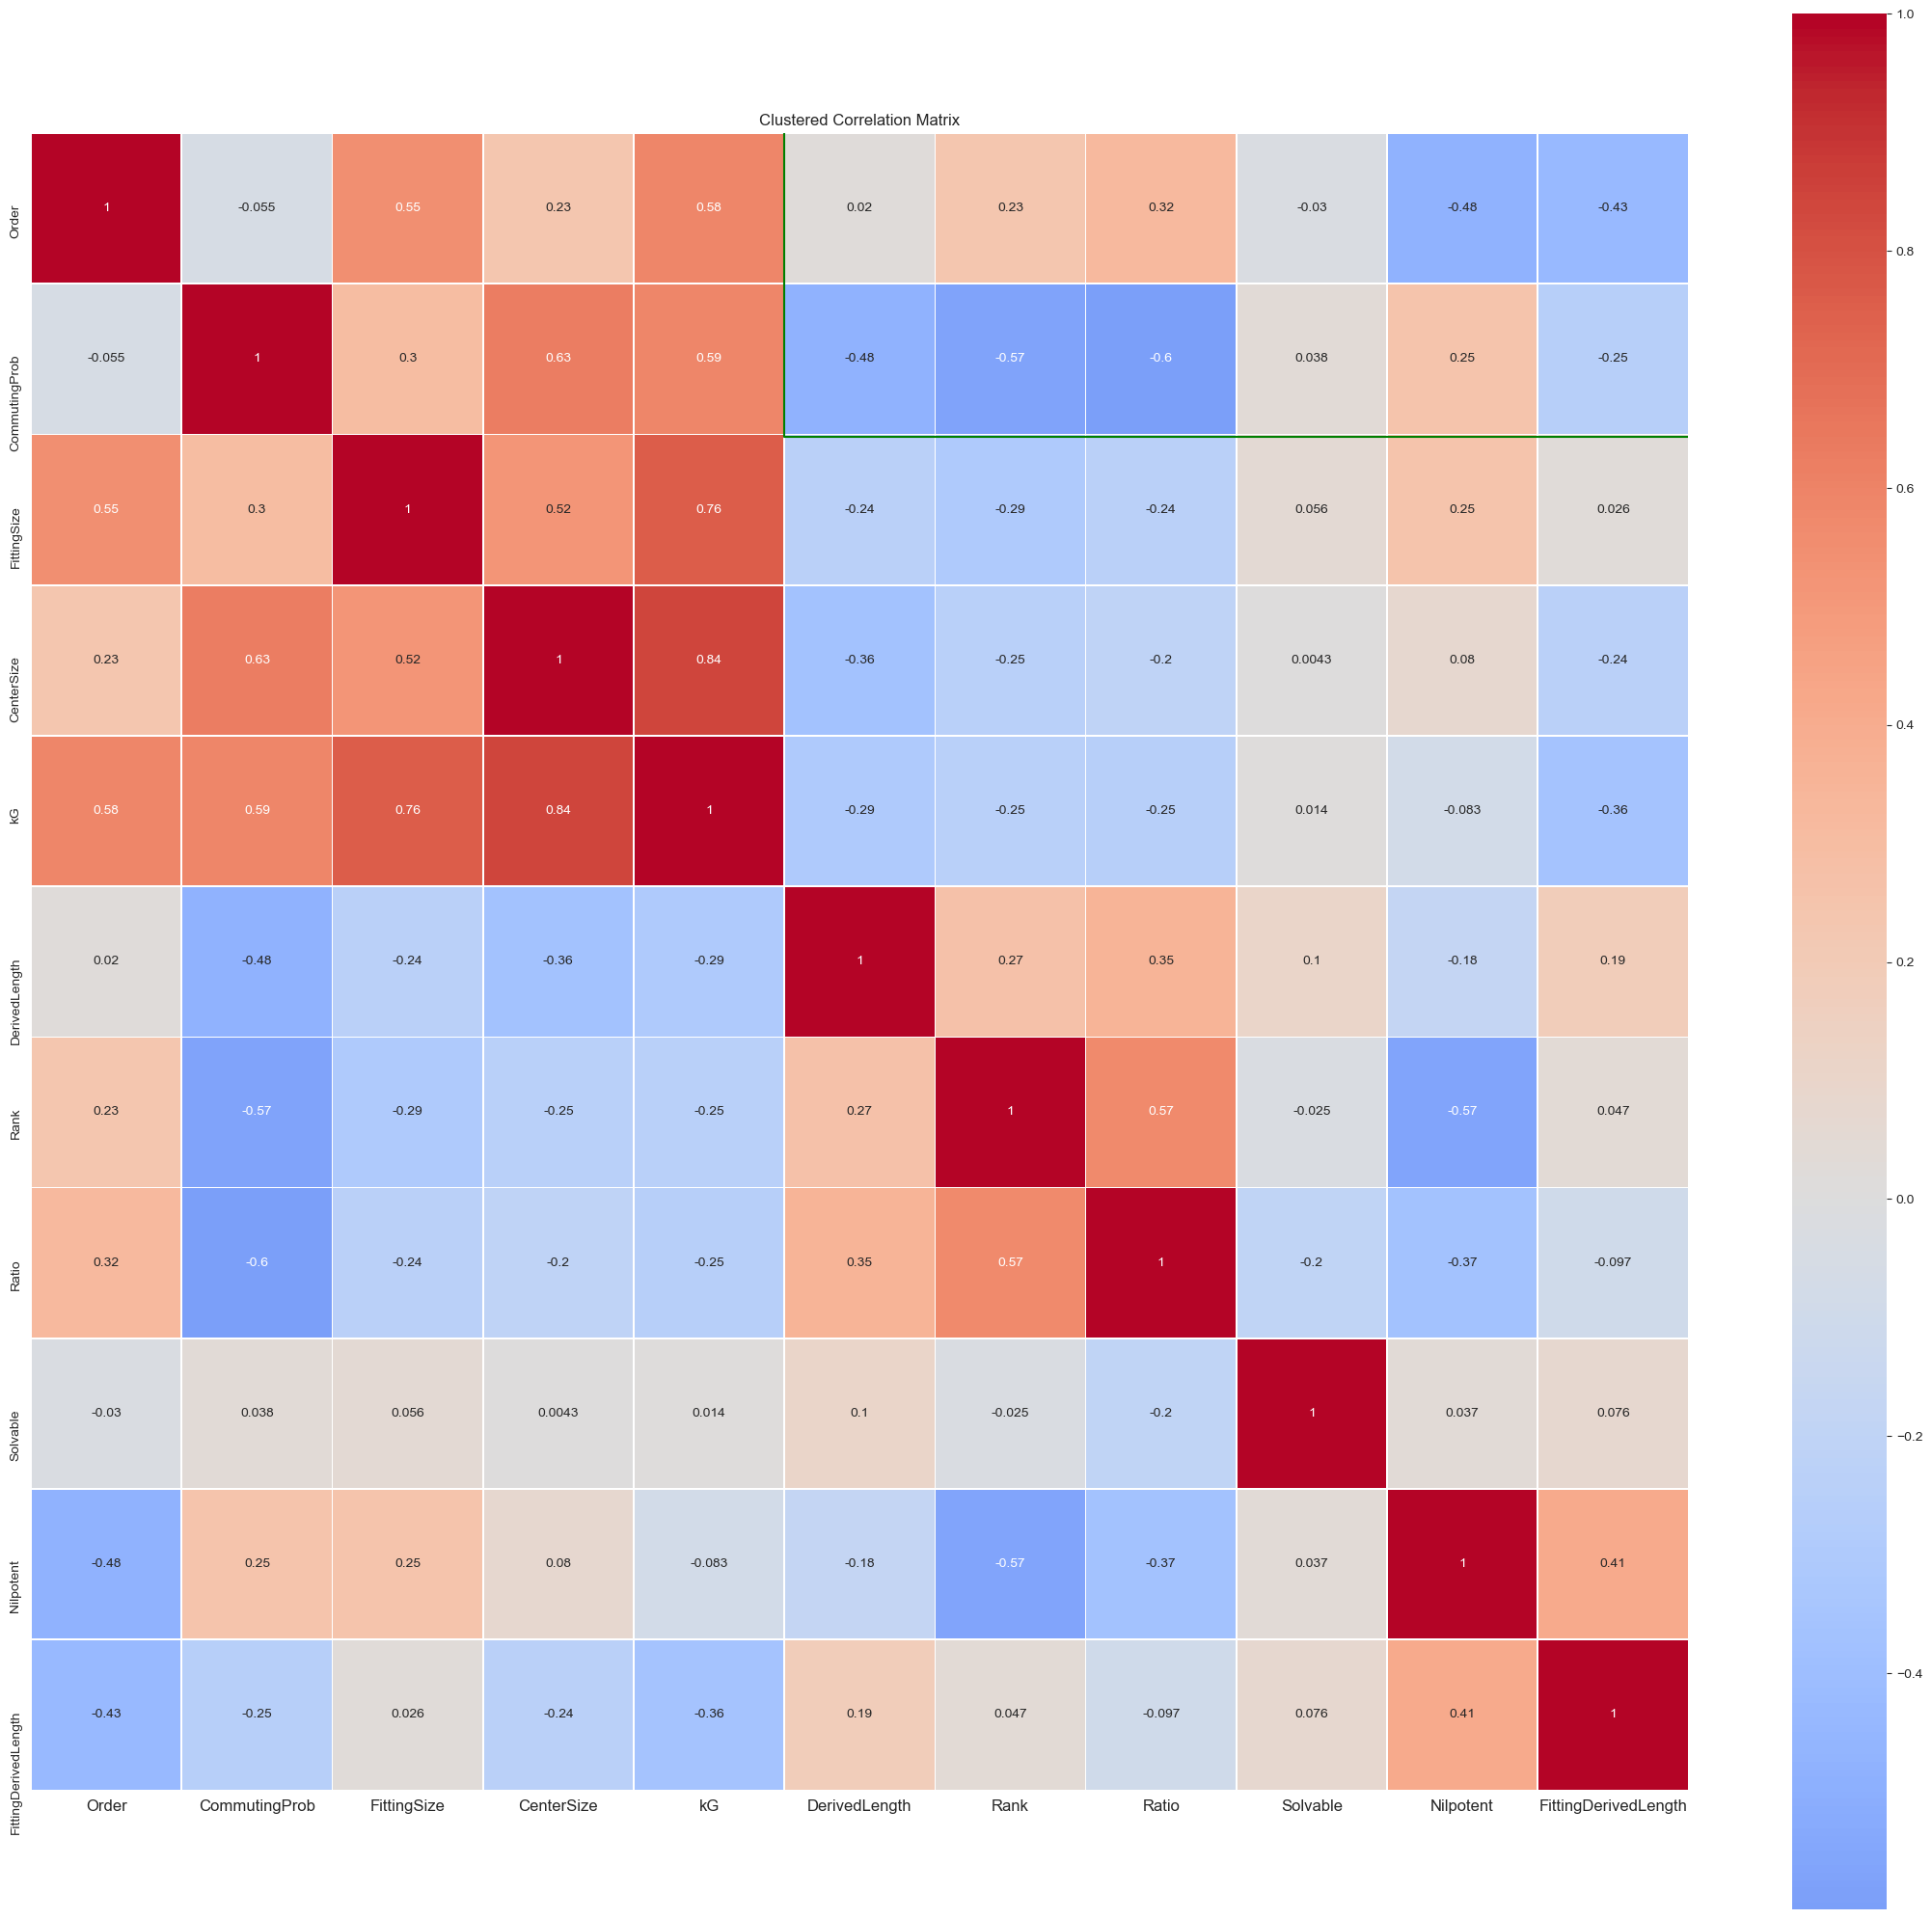

In [38]:
import scipy.cluster.hierarchy as sch

# Calculate correlation and cluster
corr_matrix = df.corr()

# Generate linkage matrix
linkage = sch.linkage(corr_matrix, method='ward')

# Create heatmap with dendrogram
plt.figure(figsize=(22, 20))

# Dendrogram
dendro = sch.dendrogram(linkage, labels=corr_matrix.columns, 
                        orientation='top', above_threshold_color='gray')

# Reorder columns based on clustering
idx = dendro['leaves']
corr_reordered = corr_matrix.iloc[idx, idx]

# Heatmap
sns.heatmap(corr_reordered, 
            annot=True,
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.5)
plt.title('Clustered Correlation Matrix')
plt.tight_layout()
plt.show()

# Non-Solvable Group Analysis

QUESTION 1: WHAT IS THE 'TYPICAL' FINITE GROUP?

=== THE 'TYPICAL' FINITE GROUP OF ORDER < 2000 ===

Order:            256 (median)
Rank:             4 (mode)
Nilpotent:        True (Yes)
Solvable:         True (Yes)
Derived Length:   2 (mode)
Commuting Prob:   0.2031 (median)
Ratio:            4.9231 (median)

=== MOST COMMON RANK VALUES ===

1      1303
2      1752
3     25914
4     28790
5     21365
6     10277
7      5331
8      2901
9      1143
10      132
Name: Rank, dtype: int64

Groups with Rank 3-5: 76069 (76.7%)

=== MOST COMMON DERIVED LENGTH ===

0        8
1     1354
2    95336
3     1910
4      576
5        1
Name: DerivedLength, dtype: int64


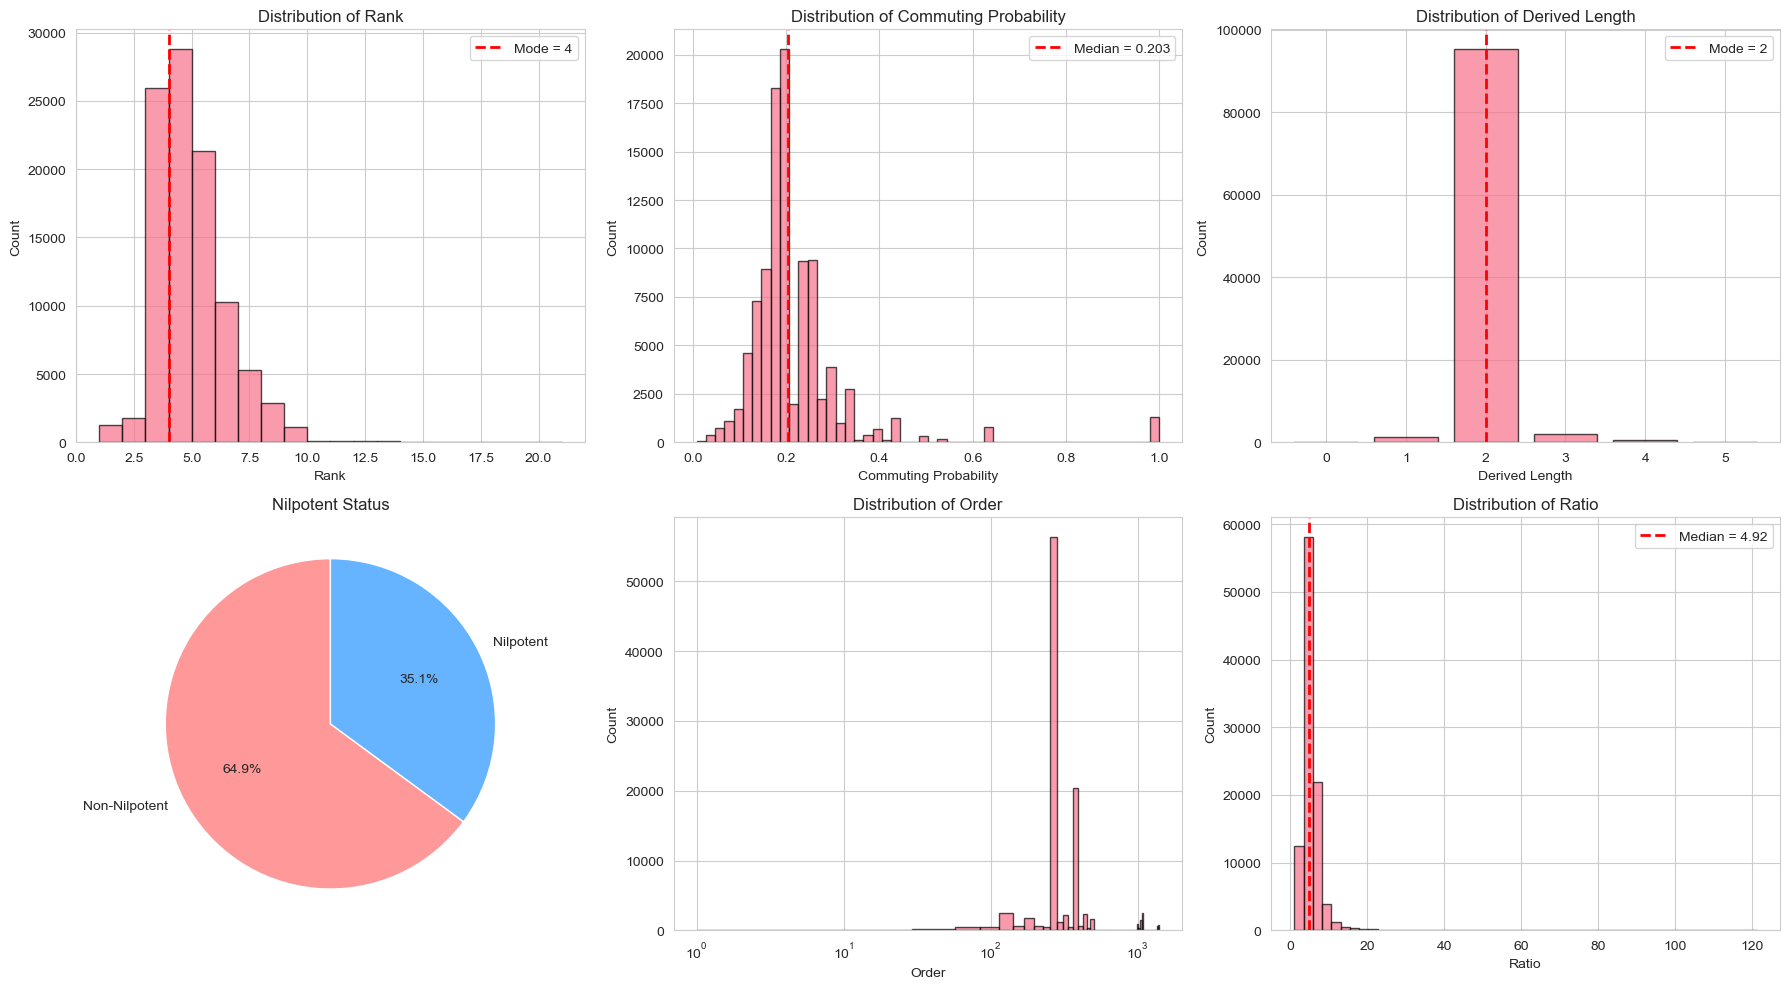


QUESTION 2: WHAT SEPARATES NILPOTENT FROM NON-NILPOTENT?

=== COMPARISON: NILPOTENT VS NON-NILPOTENT ===

Rank           : Nilpotent=3.8125 | Non-Nilpotent=5.6409 | Difference=+1.8284 (+48.0%)
CommutingProb  : Nilpotent=0.2407 | Non-Nilpotent=0.1773 | Difference=-0.0633 (-26.3%)
Ratio          : Nilpotent=4.7146 | Non-Nilpotent=6.7563 | Difference=+2.0417 (+43.3%)
Order          : Nilpotent=266.8488 | Non-Nilpotent=488.8097 | Difference=+221.9608 (+83.2%)
CenterSize     : Nilpotent=19.8960 | Non-Nilpotent=7.9864 | Difference=-11.9096 (-59.9%)
kG             : Nilpotent=68.6282 | Non-Nilpotent=83.4823 | Difference=+14.8541 (+21.6%)


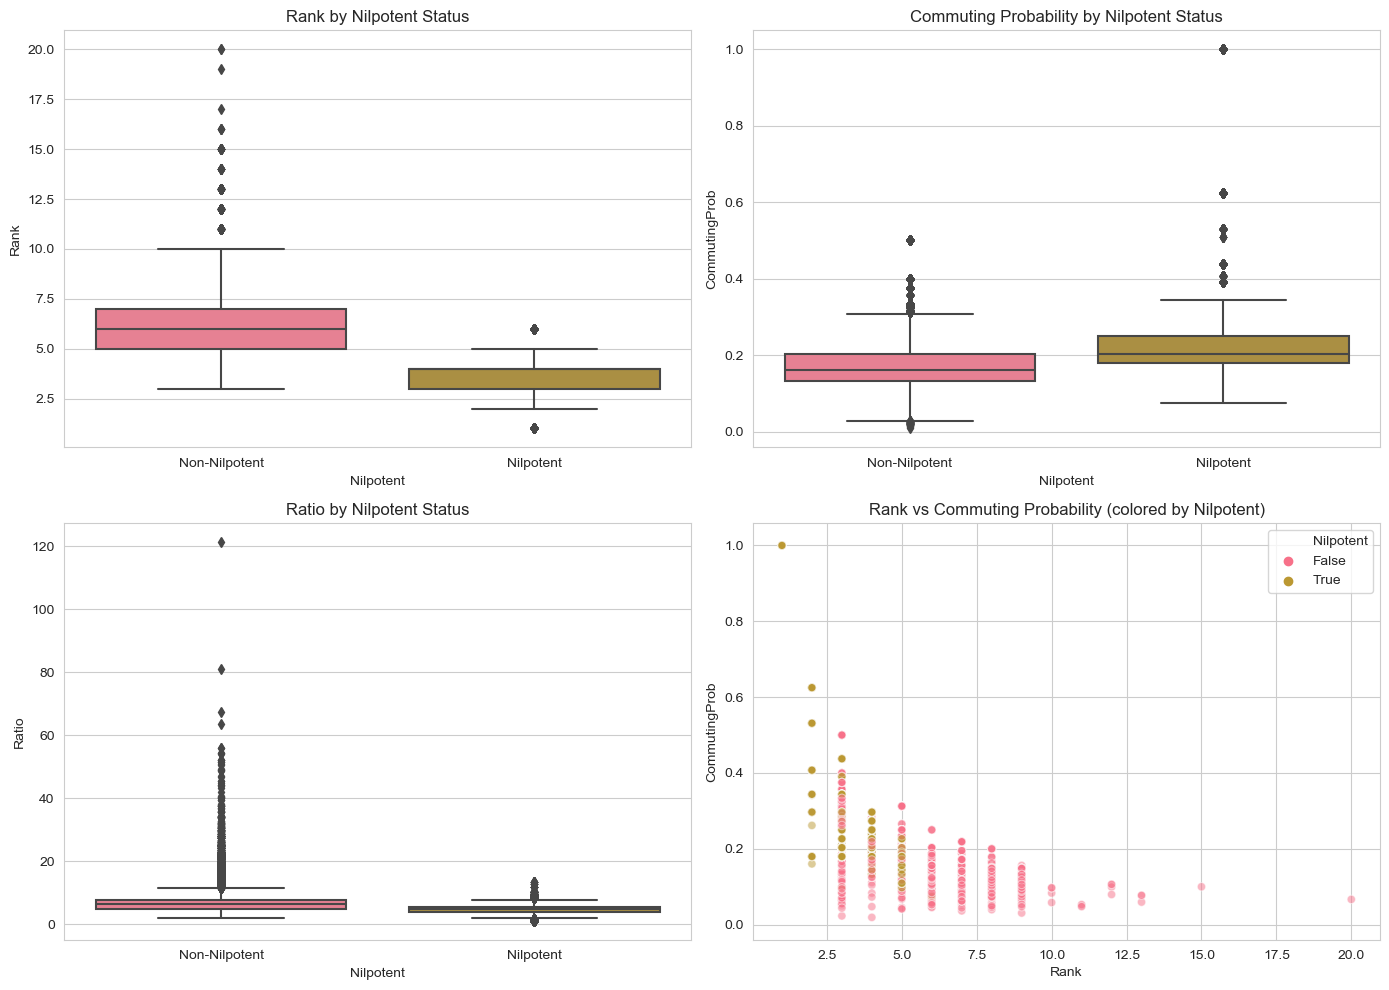


QUESTION 3: WHAT MAKES NON-SOLVABLE GROUPS SPECIAL?

Number of non-solvable groups: 74 (0.075%)
Number of solvable groups: 99111 (99.925%)

=== COMPARISON: SOLVABLE VS NON-SOLVABLE ===

Order          : Solvable=344.5467 | Non-Solvable=590.7568 | Difference=+246.2101
Rank           : Solvable=4.4530 | Non-Solvable=5.8378 | Difference=+1.3848
CommutingProb  : Solvable=0.2186 | Non-Solvable=0.0536 | Difference=-0.1650
Ratio          : Solvable=5.4168 | Non-Solvable=24.4004 | Difference=+18.9836
CenterSize     : Solvable=15.7254 | Non-Solvable=4.6892 | Difference=-11.0362
kG             : Solvable=73.8737 | Non-Solvable=29.0000 | Difference=-44.8737
DerivedLength  : Solvable=2.0178 | Non-Solvable=1.1081 | Difference=-0.9097

=== MINIMUM VALUES FOR NON-SOLVABLE GROUPS ===

Minimum Order: 60
Minimum Rank: 4
Minimum Ratio: 12.000
Maximum CommutingProb: 0.0833

=== RANK DISTRIBUTION OF NON-SOLVABLE GROUPS ===

4     35
5      7
6     12
7      5
8      5
9      2
10     3
12     4
14     1
N

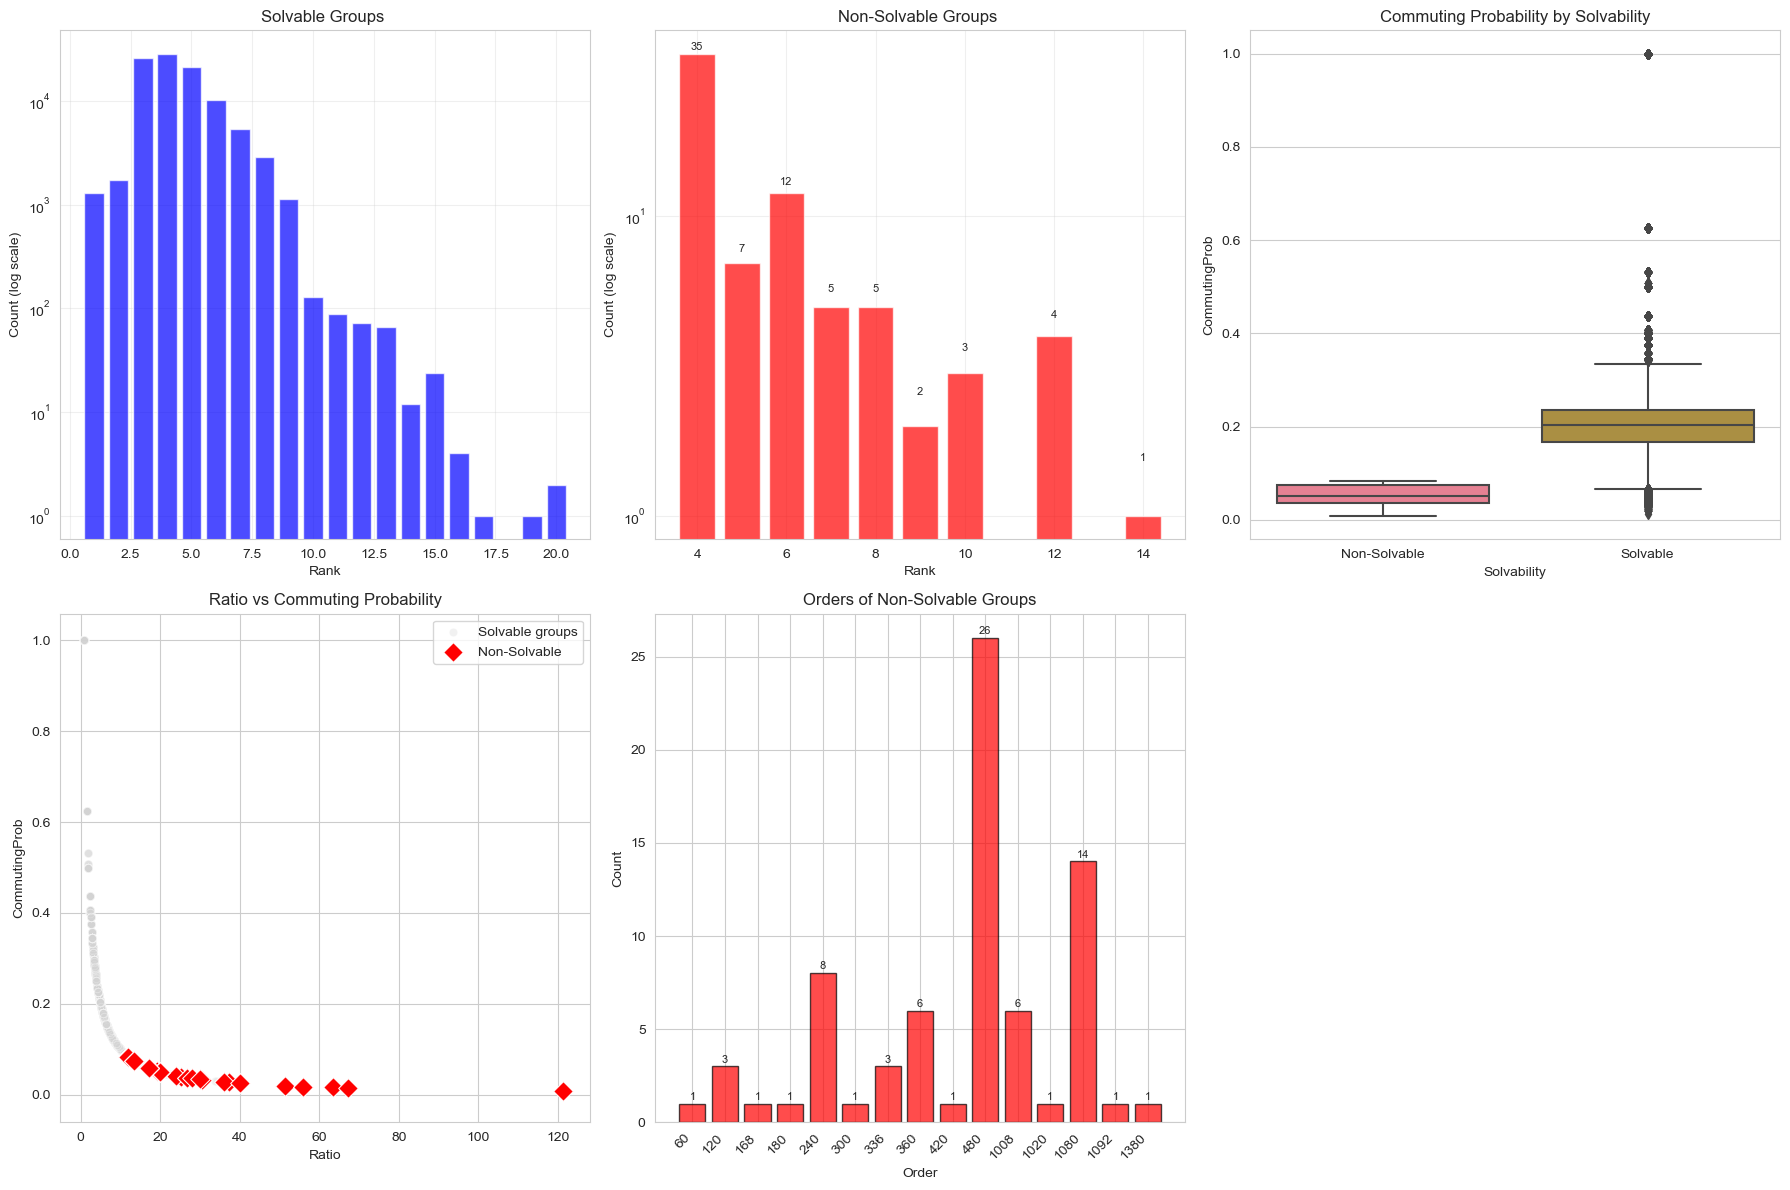


QUESTION 4: STRUCTURAL TRANSITIONS AT RANK VALUES

=== SUMMARY BY RANK ===

      CommProb_mean  CommProb_std  Count  Pct_Nilpotent  Pct_Solvable  \
Rank                                                                    
1            1.0000        0.0000   1303         1.0000        1.0000   
2            0.4661        0.1708   1752         1.0000        1.0000   
3            0.2487        0.0833  25914         0.7663        1.0000   
4            0.2255        0.0350  28790         0.9198        0.9988   
5            0.1773        0.0373  21365         0.6918        0.9997   
6            0.1462        0.0327  10277         0.0203        0.9988   
7            0.1513        0.0327   5331         0.0000        0.9991   
8            0.1250        0.0280   2901         0.0000        0.9983   
9            0.1051        0.0302   1143         0.0000        0.9983   
10           0.0806        0.0279    132         0.0000        0.9773   
11           0.0619        0.0132     88       

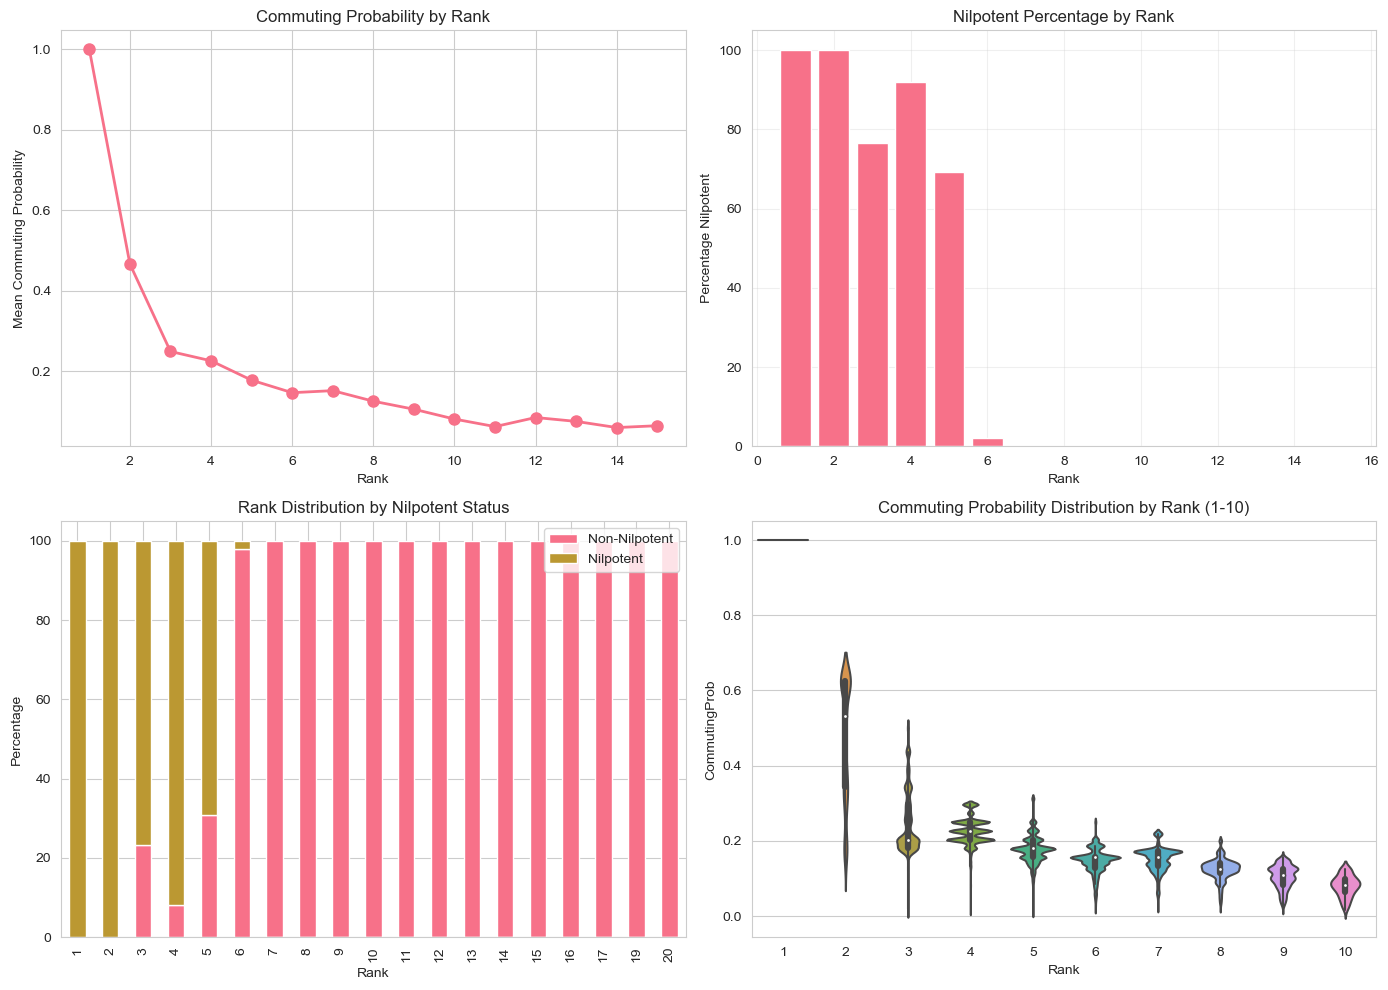


QUESTION 5: PREDICTING NILPOTENCY AND SOLVABILITY

=== PREDICTING NILPOTENT ===

Accuracy: 0.9999
Cross-validation (5-fold): 0.8864

Classification Report:
               precision    recall  f1-score   support

Non-Nilpotent       1.00      1.00      1.00      6953
    Nilpotent       1.00      1.00      1.00     12884

     accuracy                           1.00     19837
    macro avg       1.00      1.00      1.00     19837
 weighted avg       1.00      1.00      1.00     19837


=== FEATURE IMPORTANCE (Nilpotent) ===

         feature  importance
3          Order    0.461096
0           Rank    0.200992
2          Ratio    0.104346
1  CommutingProb    0.085226
5             kG    0.074782
4     CenterSize    0.073557

=== PREDICTING SOLVABLE ===

Accuracy: 0.9997
Cross-validation (5-fold): 0.8982

Classification Report:
              precision    recall  f1-score   support

Non-Solvable       1.00      0.57      0.73        14
    Solvable       1.00      1.00      1.00     1982

In [16]:
# ============================================================================
# COMPLETE ANALYSIS: Finite Groups of Order < 2000 (FIXED FOR OLDER SEABORN)
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('default')
sns.set_style("whitegrid")
sns.set_palette("husl")

# ============================================================================
# QUESTION 1: What is the "typical" finite group?
# ============================================================================

print("="*80)
print("QUESTION 1: WHAT IS THE 'TYPICAL' FINITE GROUP?")
print("="*80)

# Define "typical" as the mode/median of key variables
typical_order = df['Order'].median()
typical_rank = df['Rank'].mode()[0]
typical_nilpotent = df['Nilpotent'].mode()[0]
typical_solvable = df['Solvable'].mode()[0]
typical_derived = df['DerivedLength'].mode()[0]
typical_commprob = df['CommutingProb'].median()
typical_ratio = df['Ratio'].median()

print("\n=== THE 'TYPICAL' FINITE GROUP OF ORDER < 2000 ===\n")
print(f"Order:            {typical_order:.0f} (median)")
print(f"Rank:             {typical_rank} (mode)")
print(f"Nilpotent:        {typical_nilpotent} ({'Yes' if typical_nilpotent else 'No'})")
print(f"Solvable:         {typical_solvable} ({'Yes' if typical_solvable else 'No'})")
print(f"Derived Length:   {typical_derived:.0f} (mode)")
print(f"Commuting Prob:   {typical_commprob:.4f} (median)")
print(f"Ratio:            {typical_ratio:.4f} (median)")

# Most common group by rank
print("\n=== MOST COMMON RANK VALUES ===\n")
rank_counts = df['Rank'].value_counts().sort_index()
print(rank_counts.head(10))
print(f"\nGroups with Rank 3-5: {df[df['Rank'].between(3,5)].shape[0]} ({df[df['Rank'].between(3,5)].shape[0]/len(df)*100:.1f}%)")

# Most common derived length
print("\n=== MOST COMMON DERIVED LENGTH ===\n")
print(df['DerivedLength'].value_counts().sort_index())

# Visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Rank distribution
ax1 = axes[0, 0]
df['Rank'].hist(bins=range(1, 22), edgecolor='black', alpha=0.7, ax=ax1)
ax1.axvline(df['Rank'].mode()[0], color='red', linestyle='--', linewidth=2, label=f"Mode = {df['Rank'].mode()[0]}")
ax1.set_xlabel('Rank')
ax1.set_ylabel('Count')
ax1.set_title('Distribution of Rank')
ax1.legend()

# 2. CommutingProb distribution
ax2 = axes[0, 1]
df['CommutingProb'].hist(bins=50, edgecolor='black', alpha=0.7, ax=ax2)
ax2.axvline(df['CommutingProb'].median(), color='red', linestyle='--', linewidth=2, label=f"Median = {df['CommutingProb'].median():.3f}")
ax2.set_xlabel('Commuting Probability')
ax2.set_ylabel('Count')
ax2.set_title('Distribution of Commuting Probability')
ax2.legend()

# 3. Derived Length
ax3 = axes[0, 2]
dl_counts = df['DerivedLength'].value_counts().sort_index()
ax3.bar(dl_counts.index, dl_counts.values, edgecolor='black', alpha=0.7)
ax3.axvline(df['DerivedLength'].mode()[0], color='red', linestyle='--', linewidth=2, label=f"Mode = {df['DerivedLength'].mode()[0]:.0f}")
ax3.set_xlabel('Derived Length')
ax3.set_ylabel('Count')
ax3.set_title('Distribution of Derived Length')
ax3.legend()

# 4. Nilpotent vs Solvable pie chart
ax4 = axes[1, 0]
nilpotent_counts = df['Nilpotent'].value_counts()
colors = ['#ff9999','#66b3ff']
ax4.pie(nilpotent_counts, labels=['Non-Nilpotent', 'Nilpotent'], autopct='%1.1f%%', 
        colors=colors, startangle=90)
ax4.set_title('Nilpotent Status')

# 5. Order distribution (log scale)
ax5 = axes[1, 1]
df['Order'].hist(bins=50, edgecolor='black', alpha=0.7, ax=ax5)
ax5.set_xlabel('Order')
ax5.set_ylabel('Count')
ax5.set_title('Distribution of Order')
ax5.set_xscale('log')

# 6. Ratio distribution
ax6 = axes[1, 2]
df['Ratio'].hist(bins=50, edgecolor='black', alpha=0.7, ax=ax6)
ax6.axvline(df['Ratio'].median(), color='red', linestyle='--', linewidth=2, label=f"Median = {df['Ratio'].median():.2f}")
ax6.set_xlabel('Ratio')
ax6.set_ylabel('Count')
ax6.set_title('Distribution of Ratio')
ax6.legend()

plt.tight_layout()
plt.show()

# ============================================================================
# QUESTION 2: What separates nilpotent from non-nilpotent?
# ============================================================================

print("\n" + "="*80)
print("QUESTION 2: WHAT SEPARATES NILPOTENT FROM NON-NILPOTENT?")
print("="*80)

# Compare nilpotent vs non-nilpotent
nilp = df[df['Nilpotent'] == True]
non_nilp = df[df['Nilpotent'] == False]

print("\n=== COMPARISON: NILPOTENT VS NON-NILPOTENT ===\n")

comparison_cols = ['Rank', 'CommutingProb', 'Ratio', 'Order', 'CenterSize', 'kG']
for col in comparison_cols:
    nilp_mean = nilp[col].mean()
    non_nilp_mean = non_nilp[col].mean()
    diff = non_nilp_mean - nilp_mean
    pct_diff = (diff / nilp_mean) * 100
    print(f"{col:15s}: Nilpotent={nilp_mean:.4f} | Non-Nilpotent={non_nilp_mean:.4f} | "
          f"Difference={diff:+.4f} ({pct_diff:+.1f}%)")

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Rank boxplot
ax1 = axes[0, 0]
sns.boxplot(data=df, x='Nilpotent', y='Rank', ax=ax1)
ax1.set_title('Rank by Nilpotent Status')
ax1.set_xticklabels(['Non-Nilpotent', 'Nilpotent'])

# 2. CommutingProb boxplot
ax2 = axes[0, 1]
sns.boxplot(data=df, x='Nilpotent', y='CommutingProb', ax=ax2)
ax2.set_title('Commuting Probability by Nilpotent Status')
ax2.set_xticklabels(['Non-Nilpotent', 'Nilpotent'])

# 3. Ratio boxplot
ax3 = axes[1, 0]
sns.boxplot(data=df, x='Nilpotent', y='Ratio', ax=ax3)
ax3.set_title('Ratio by Nilpotent Status')
ax3.set_xticklabels(['Non-Nilpotent', 'Nilpotent'])

# 4. Scatter: Rank vs CommutingProb colored by Nilpotent
ax4 = axes[1, 1]
sample = df.sample(min(5000, len(df)))
sns.scatterplot(data=sample, x='Rank', y='CommutingProb', hue='Nilpotent', alpha=0.5, ax=ax4)
ax4.set_title('Rank vs Commuting Probability (colored by Nilpotent)')

plt.tight_layout()
plt.show()

# ============================================================================
# QUESTION 3: What makes non-solvable groups special? (MODIFIED FOR VISIBILITY)
# ============================================================================

print("\n" + "="*80)
print("QUESTION 3: WHAT MAKES NON-SOLVABLE GROUPS SPECIAL?")
print("="*80)

non_solv = df[df['Solvable'] == False]
solv = df[df['Solvable'] == True]

print(f"\nNumber of non-solvable groups: {len(non_solv)} ({len(non_solv)/len(df)*100:.3f}%)")
print(f"Number of solvable groups: {len(solv)} ({len(solv)/len(df)*100:.3f}%)")

print("\n=== COMPARISON: SOLVABLE VS NON-SOLVABLE ===\n")
for col in ['Order', 'Rank', 'CommutingProb', 'Ratio', 'CenterSize', 'kG', 'DerivedLength']:
    solv_mean = solv[col].mean()
    non_solv_mean = non_solv[col].mean()
    print(f"{col:15s}: Solvable={solv_mean:.4f} | Non-Solvable={non_solv_mean:.4f} | "
          f"Difference={non_solv_mean - solv_mean:+.4f}")

print("\n=== MINIMUM VALUES FOR NON-SOLVABLE GROUPS ===\n")
print(f"Minimum Order: {non_solv['Order'].min()}")
print(f"Minimum Rank: {non_solv['Rank'].min()}")
print(f"Minimum Ratio: {non_solv['Ratio'].min():.3f}")
print(f"Maximum CommutingProb: {non_solv['CommutingProb'].max():.4f}")

print("\n=== RANK DISTRIBUTION OF NON-SOLVABLE GROUPS ===\n")
print(non_solv['Rank'].value_counts().sort_index())

print("\n=== ORDER DISTRIBUTION OF NON-SOLVABLE GROUPS ===\n")
print(non_solv['Order'].value_counts().sort_index().head(15))

# ========== MODIFIED VISUALIZATION FOR QUESTION 3 (WITHOUT PLOT 1) ==========
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# PLOT 1: Solvable groups with log scale
ax1 = axes[0, 0]
solv_ranks = df[df['Solvable'] == True]['Rank'].value_counts().sort_index()
ax1.bar(solv_ranks.index, solv_ranks.values, alpha=0.7, color='blue', width=0.8)
ax1.set_title(f'Solvable Groups ')
ax1.set_xlabel('Rank')
ax1.set_ylabel('Count (log scale)')
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3)

# PLOT 2: Non-solvable groups with log scale
ax2 = axes[0, 1]
non_solv_ranks = df[df['Solvable'] == False]['Rank'].value_counts().sort_index()
ax2.bar(non_solv_ranks.index, non_solv_ranks.values, alpha=0.7, color='red', width=0.8)
# Add count labels on bars
for rank, count in non_solv_ranks.items():
    if count > 0:
        ax2.text(rank, count + 0.5, str(count), ha='center', va='bottom', fontsize=8)
ax2.set_title(f'Non-Solvable Groups ')
ax2.set_xlabel('Rank')
ax2.set_ylabel('Count (log scale)')
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3)

# PLOT 3: CommutingProb boxplot
ax3 = axes[0, 2]
sns.boxplot(data=df, x='Solvable', y='CommutingProb', ax=ax3)
ax3.set_title('Commuting Probability by Solvability')
ax3.set_xticklabels(['Non-Solvable', 'Solvable'])
ax3.set_xlabel('Solvability')

# PLOT 4: Ratio vs CommutingProb with non-solvable highlighted
ax4 = axes[1, 0]
# Plot all groups as small transparent dots
sample = df.sample(min(5000, len(df)))
sns.scatterplot(data=sample, x='Ratio', y='CommutingProb', 
                color='lightgray', alpha=0.3, ax=ax4, label='Solvable groups')
# Overlay non-solvable in bright red with larger size
non_solv_sample = df[df['Solvable'] == False].sample(min(500, len(df[df['Solvable'] == False])))
if len(non_solv_sample) > 0:
    sns.scatterplot(data=non_solv_sample, x='Ratio', y='CommutingProb', 
                    color='red', s=100, marker='D', ax=ax4, label='Non-Solvable')
ax4.set_title('Ratio vs Commuting Probability')
ax4.legend()

# PLOT 5: Order distribution of non-solvable groups
ax5 = axes[1, 1]
if len(non_solv) > 0:
    order_counts = non_solv['Order'].value_counts().sort_index().head(20)
    bars = ax5.bar(order_counts.index.astype(str), order_counts.values, 
                   color='red', alpha=0.7, edgecolor='black')
    ax5.set_title('Orders of Non-Solvable Groups')
    ax5.set_xlabel('Order')
    ax5.set_ylabel('Count')
    # Add count labels on bars
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax5.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                    f'{int(height)}', ha='center', va='bottom', fontsize=8)
    plt.setp(ax5.get_xticklabels(), rotation=45, ha='right')

# Remove the empty subplot (6th position)
ax6 = axes[1, 2]
ax6.axis('off')

plt.tight_layout()
plt.show()

# ============================================================================
# QUESTION 4: What are the "structural transitions" at Rank values?
# ============================================================================

print("\n" + "="*80)
print("QUESTION 4: STRUCTURAL TRANSITIONS AT RANK VALUES")
print("="*80)

rank_summary = df.groupby('Rank').agg({
    'CommutingProb': ['mean', 'std', 'count'],
    'Nilpotent': 'mean',
    'Solvable': 'mean',
    'Ratio': 'mean'
}).round(4)
rank_summary.columns = ['CommProb_mean', 'CommProb_std', 'Count', 'Pct_Nilpotent', 'Pct_Solvable', 'Ratio_mean']

print("\n=== SUMMARY BY RANK ===\n")
print(rank_summary.head(15))

# Calculate transitions
rank_summary['CommProb_drop'] = rank_summary['CommProb_mean'].diff()
rank_summary['CommProb_pct_drop'] = (rank_summary['CommProb_drop'] / rank_summary['CommProb_mean'].shift(1)) * 100

print("\n=== TRANSITION EFFECTS (Commuting Probability drops) ===\n")
print(rank_summary[['CommProb_mean', 'CommProb_drop', 'CommProb_pct_drop', 'Pct_Nilpotent']].head(10))

# Find where non-solvable groups appear
first_non_solv_rank = df[df['Solvable'] == False]['Rank'].min()
print(f"\nFirst non-solvable group appears at Rank: {first_non_solv_rank}")

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. CommutingProb by Rank
ax1 = axes[0, 0]
ax1.plot(rank_summary.index[:15], rank_summary['CommProb_mean'][:15], 'o-', linewidth=2, markersize=8)
ax1.set_xlabel('Rank')
ax1.set_ylabel('Mean Commuting Probability')
ax1.set_title('Commuting Probability by Rank')
ax1.grid(True)

# 2. Percentage Nilpotent by Rank
ax2 = axes[0, 1]
ax2.bar(rank_summary.index[:15], rank_summary['Pct_Nilpotent'][:15] * 100)
ax2.set_xlabel('Rank')
ax2.set_ylabel('Percentage Nilpotent')
ax2.set_title('Nilpotent Percentage by Rank')
ax2.grid(True, alpha=0.3)

# 3. Rank distribution by Nilpotent status (using bar plot)
ax3 = axes[1, 0]
rank_nilp_counts = pd.crosstab(df['Rank'], df['Nilpotent'])
rank_nilp_counts_pct = rank_nilp_counts.div(rank_nilp_counts.sum(axis=1), axis=0) * 100
rank_nilp_counts_pct.plot(kind='bar', stacked=True, ax=ax3)
ax3.set_xlabel('Rank')
ax3.set_ylabel('Percentage')
ax3.set_title('Rank Distribution by Nilpotent Status')
ax3.legend(['Non-Nilpotent', 'Nilpotent'])

# 4. CommutingProb vs Rank with confidence
ax4 = axes[1, 1]
sns.violinplot(data=df[df['Rank'] <= 10], x='Rank', y='CommutingProb', ax=ax4)
ax4.set_title('Commuting Probability Distribution by Rank (1-10)')

plt.tight_layout()
plt.show()

# ============================================================================
# QUESTION 5: Can we predict nilpotency/solvability from invariants?
# ============================================================================

print("\n" + "="*80)
print("QUESTION 5: PREDICTING NILPOTENCY AND SOLVABILITY")
print("="*80)

# Prepare features
features = ['Rank', 'CommutingProb', 'Ratio', 'Order', 'CenterSize', 'kG']
X = df[features].copy()
X_scaled = StandardScaler().fit_transform(X)

# ===== PREDICT NILPOTENT =====
y_nilp = df['Nilpotent']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_nilp, test_size=0.2, random_state=42)

# Random Forest
rf_nilp = RandomForestClassifier(n_estimators=100, random_state=42)
rf_nilp.fit(X_train, y_train)
y_pred_nilp = rf_nilp.predict(X_test)

print("\n=== PREDICTING NILPOTENT ===\n")
print(f"Accuracy: {accuracy_score(y_test, y_pred_nilp):.4f}")
print(f"Cross-validation (5-fold): {cross_val_score(rf_nilp, X_scaled, y_nilp, cv=5).mean():.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nilp, target_names=['Non-Nilpotent', 'Nilpotent']))

# Feature importance for nilpotent
importance_nilp = pd.DataFrame({
    'feature': features,
    'importance': rf_nilp.feature_importances_
}).sort_values('importance', ascending=False)

print("\n=== FEATURE IMPORTANCE (Nilpotent) ===\n")
print(importance_nilp)

# ===== PREDICT SOLVABLE =====
y_solv = df['Solvable']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_solv, test_size=0.2, random_state=42)

# Random Forest
rf_solv = RandomForestClassifier(n_estimators=100, random_state=42)
rf_solv.fit(X_train, y_train)
y_pred_solv = rf_solv.predict(X_test)

print("\n=== PREDICTING SOLVABLE ===\n")
print(f"Accuracy: {accuracy_score(y_test, y_pred_solv):.4f}")
print(f"Cross-validation (5-fold): {cross_val_score(rf_solv, X_scaled, y_solv, cv=5).mean():.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_solv, target_names=['Non-Solvable', 'Solvable']))

# Feature importance for solvable
importance_solv = pd.DataFrame({
    'feature': features,
    'importance': rf_solv.feature_importances_
}).sort_values('importance', ascending=False)

print("\n=== FEATURE IMPORTANCE (Solvable) ===\n")
print(importance_solv)

# ===== LOGISTIC REGRESSION FOR COMPARISON =====
print("\n=== LOGISTIC REGRESSION (Simpler Model) ===\n")

# For nilpotent
lr_nilp = LogisticRegression(max_iter=1000, random_state=42)
lr_nilp.fit(X_train, y_train)
print(f"Logistic Regression - Nilpotent Accuracy: {lr_nilp.score(X_test, y_test):.4f}")

# For solvable
lr_solv = LogisticRegression(max_iter=1000, random_state=42)
lr_solv.fit(X_train, y_train)
print(f"Logistic Regression - Solvable Accuracy: {lr_solv.score(X_test, y_test):.4f}")

# ============================================================================
# SUMMARY TABLE
# ============================================================================

print("\n" + "="*80)
print("FINAL SUMMARY TABLE")
print("="*80)

summary_df = pd.DataFrame({
    'Metric': ['Total Groups', 'Typical Rank', 'Typical Derived Length', 
               'Nilpotent %', 'Solvable %', 'Non-Solvable Count',
               'Mean CommutingProb', 'Mean Ratio'],
    'Value': [
        len(df),
        df['Rank'].mode()[0],
        df['DerivedLength'].mode()[0],
        f"{df['Nilpotent'].mean()*100:.1f}%",
        f"{df['Solvable'].mean()*100:.1f}%",
        len(df[df['Solvable'] == False]),
        f"{df['CommutingProb'].mean():.4f}",
        f"{df['Ratio'].mean():.4f}"
    ]
})

print(summary_df.to_string(index=False))

print("\n" + "="*80)
print("ANALYSIS COMPLETE!")
print("="*80)